# HW02-1：股票收益与组合风险分析

- **姓名：**朱家瑞
- **学号：**待填写（坚果云提交前补充完整学号）
- **作业简介或教师作业页面链接：**https://lianxhcn.github.io/FinEco/exercises/hw-02.html
- **个人 GitHub 仓库访问地址：**https://github.com/Jaremy112/fineco-homework
- **HW02-1 目录链接：**https://github.com/Jaremy112/fineco-homework/tree/main/hw-02
- **HW02-2 目录链接：**待完成HW02-2后补充
- **数据来源、获取日期与样本期间：**AKShare 1.18.39（新浪财经日行情、巨潮资讯股本变动）为主要数据源，CSMAR上市公司基本信息年度表用于统一简称、上市日期及2025年末行业分类，Wind金融数据服务用于关键字段交叉核验；获取日期为2026-09-18；正式样本为2021-01-01至2026-09-16，并补充每只股票在2021年前最后一个有效交易日用于计算首个日收益率。
- **AI 使用声明：**使用了Hermes Agent（Codex）辅助读取教师作业要求、设计数据获取与审计流程、编写和检查Python代码；使用Wind MCP调用万得金融数据服务。股票池、字段口径、异常处理和结论由本人核对，Notebook保留数据来源、参数、实际输出和局限说明。

## 分析目的与总体思路

本文选择10只至少覆盖5个CSMAR行业、且均在样本开始前上市的A股，先取得不复权收盘价、经公司行为调整的复权收盘价、成交量、成交额和历史总市值，再检查主键、日期、覆盖、缺失、停牌和异常收益。在统一的数据口径上，依次完成价格与累计收益图、日收益及滚动波动率、描述统计、相关性分析，并比较每日等权与使用上一交易日总市值确定权重的市值加权组合。分析遵循“说明—代码与实际输出—结果解读”的结构。

## 1. 选股与获取数据

### Step 1：Markdown分析说明

本节要回答两个问题：第一，所选10只股票是否满足至少覆盖5个行业、在2021年以前上市且不依据样本期事后涨幅选取；第二，取得的数据是否覆盖作业要求的价格、收益率、流动性和历史总市值口径。先冻结股票池再下载，可以避免根据2021—2026年的实际表现替换股票而产生事后选择。

本作业优先使用AKShare获取行情：不复权和后复权日行情来自新浪财经接口，股本变动来自巨潮资讯接口。由于本题要求历史**总市值**，而新浪行情接口只直接提供流通股本，本文用巨潮资讯按变动日期记录的总股本与同日不复权收盘价构造历史总市值；不使用流通市值，也不使用复权价格乘股本。Wind用于股票档案、统一行业分类和关键日期的总市值交叉核验，以减少代码、日期、单位和口径误判。复权价格仅作为连续收益分析尺度，不视为历史实际成交价。

分析要点和口径如下：

- 股票池：10只A股，统一采用CSMAR上市公司基本信息年度表中的2025年末行业分类，数据读取日期为2026-09-18；
- 选股依据：行业、商业模式和代表性，不以样本期事后涨幅为依据；
- 样本：2021-01-01至2026-09-16，并补充2020年最后一个有效交易日；
- 价格：新浪财经不复权收盘价用于价格时序图；新浪财经后复权收盘价用于日简单收益率；
- 流动性：新浪财经成交量原始单位为股；成交额由元转换为亿元；
- 市值：巨潮资讯总股本原始单位为万股，按变动日期向后匹配；历史总市值（亿元）=`不复权收盘价×总股本（万股）/10000`；
- 组合权重：交易日 $t$ 的市值权重只使用 $t-1$ 日历史总市值；
- 获取审计：保留原始CSV、接口参数、字段单位、覆盖、SHA-256和处理后数据；
- 交叉核验：以贵州茅台2020-12-31为例，将构造总市值与Wind同日历史总市值比较。

### 选股表

| 代码 | 简称 | 行业 | 上市日期 | 选股理由 |
|---|---|---|---|---|
| 600519.SH | 贵州茅台 | 酒、饮料和精制茶制造业 | 2001-08-27 | 消费品牌代表，覆盖品牌型商业模式 |
| 600036.SH | 招商银行 | 货币金融服务 | 2002-04-09 | 银行业代表，覆盖金融中介业务 |
| 600276.SH | 恒瑞医药 | 医药制造业 | 2000-10-18 | 医药制造代表，覆盖研发驱动模式 |
| 000333.SZ | 美的集团 | 电气机械和器材制造业 | 2013-09-18 | 家电制造代表，覆盖耐用消费与制造 |
| 002594.SZ | 比亚迪 | 汽车制造业 | 2011-06-30 | 汽车制造代表，覆盖技术投入与产业链 |
| 600309.SH | 万华化学 | 化学原料和化学制品制造业 | 2001-01-05 | 化工材料代表，覆盖周期制造与研发投入 |
| 002352.SZ | 顺丰控股 | 邮政业 | 2010-02-05 | 物流服务代表，覆盖网络型服务商业模式 |
| 600030.SH | 中信证券 | 资本市场服务 | 2003-01-06 | 证券业代表，补充非银行金融模式 |
| 601012.SH | 隆基绿能 | 电气机械和器材制造业 | 2012-04-11 | 新能源设备代表，覆盖制造周期 |
| 002475.SZ | 立讯精密 | 计算机、通信和其他电子设备制造业 | 2010-09-15 | 电子制造代表，覆盖消费电子供应链 |

上述10只股票覆盖9个CSMAR行业，全部在2021-01-01之前上市。股票池不是依据2021—2026年已实现涨幅事后筛选，而是依据行业、商业模式和代表性事先确定。

### 数据来源与接口说明

本题的数据源可以使用，但实际获取采用分工明确的组合，而不是把所有数据强行交给单一数据库：

- **AKShare 1.18.39 / 新浪财经 `stock_zh_a_daily`**：获取不复权日收盘价、后复权日收盘价、成交量和成交额；
- **AKShare 1.18.39 / 巨潮资讯 `stock_share_change_cninfo`**：获取总股本及股本变动日期，用于构造历史总市值；
- **CSMAR上市公司基本信息年度表**：统一获取简称、上市日期和2025年末行业分类；
- **Wind金融数据服务**：用于股票档案和贵州茅台关键日期总市值交叉核验。Wind全量行情调用因账户积分余额不足未采用，不影响本题使用AKShare完成数据获取。

因此，本题并不是“AKShare或CSMAR不能用”，而是：AKShare负责行情和股本，CSMAR负责统一选股信息，Wind负责交叉核验。所有原始返回和处理后数据均已保存到本Notebook同目录的`data/raw/akshare/`和`data/processed/`。


### Step 2：代码与实际输出

下面先显示本次运行环境，再展示冻结后的选股表、数据来源清单、各股票覆盖情况、主键检查和历史总市值交叉核验。

In [1]:
# 导入本节所需包并设置显示选项
from pathlib import Path
import json
import platform
import pandas as pd
from IPython.display import display

PROJECT = Path.cwd()
if not (PROJECT / "audit" / "source_manifest_akshare.csv").exists():
    # 允许从个人仓库根目录启动Notebook
    candidate = Path.cwd() / "hw-02"
    if (candidate / "audit" / "source_manifest_akshare.csv").exists():
        PROJECT = candidate
    else:
        raise FileNotFoundError("未找到HW02-1审计文件，请先运行数据下载脚本。")

pd.set_option("display.max_colwidth", 60)
print("Python:", platform.python_version())
print("pandas:", pd.__version__)
print("项目目录:", PROJECT.resolve())

Python: 3.12.12
pandas: 2.3.3
项目目录: /Users/macbookairzhu/Documents/fineco-homework/hw-02


In [2]:
# 从唯一股票池主表读取10只股票及统一的CSMAR 2025年末行业分类
selection_master_path = PROJECT / "data" / "processed" / "stock_selection_master.csv"
selection_master = pd.read_csv(
    selection_master_path,
    dtype={"stock_code": "string", "symbol": "string"},
    parse_dates=["listing_date", "industry_classification_date", "industry_source_read_date", "sample_start", "sample_end"],
)

required_columns = [
    "stock_code", "stock_name", "industry", "listing_date", "selection_reason",
    "industry_standard", "industry_classification_date", "industry_source",
    "industry_source_read_date", "listed_before_sample",
]
missing_columns = sorted(set(required_columns) - set(selection_master.columns))
if missing_columns:
    raise ValueError(f"股票池主表缺少字段: {missing_columns}")
if len(selection_master) != 10 or selection_master["stock_code"].duplicated().any():
    raise ValueError("股票池主表必须恰好包含10只不重复股票")

selection = selection_master[[
    "stock_code", "stock_name", "industry", "listing_date", "selection_reason",
    "listed_before_sample", "industry_standard", "industry_classification_date",
    "industry_source", "industry_source_read_date",
]].rename(columns={
    "stock_code": "股票代码",
    "stock_name": "股票简称",
    "industry": "CSMAR行业（2025年末）",
    "listing_date": "上市日期",
    "selection_reason": "选股理由",
    "listed_before_sample": "2021年前上市",
    "industry_standard": "行业分类标准",
    "industry_classification_date": "行业分类日期",
    "industry_source": "行业分类来源",
    "industry_source_read_date": "来源读取日期",
})

display(selection)
print("股票池主表:", selection_master_path.resolve())
print("股票数:", len(selection))
print("CSMAR行业数量:", selection["CSMAR行业（2025年末）"].nunique())
print("全部在样本前上市:", bool(selection["2021年前上市"].all()))

,股票代码,股票简称,CSMAR行业（2025年末）,上市日期,选股理由,2021年前上市,行业分类标准,行业分类日期,行业分类来源,来源读取日期
0,600519.SH,贵州茅台,酒、饮料和精制茶制造业,2001-08-27,消费品牌代表，覆盖品牌型商业模式,True,CSMAR上市公司行业分类,2025-12-31,CSMAR上市公司基本信息年度表,2026-09-18
1,600036.SH,招商银行,货币金融服务,2002-04-09,银行业代表，覆盖金融中介业务,True,CSMAR上市公司行业分类,2025-12-31,CSMAR上市公司基本信息年度表,2026-09-18
2,600276.SH,恒瑞医药,医药制造业,2000-10-18,医药制造代表，覆盖研发驱动模式,True,CSMAR上市公司行业分类,2025-12-31,CSMAR上市公司基本信息年度表,2026-09-18
3,000333.SZ,美的集团,电气机械和器材制造业,2013-09-18,家电制造代表，覆盖耐用消费与制造,True,CSMAR上市公司行业分类,2025-12-31,CSMAR上市公司基本信息年度表,2026-09-18
4,002594.SZ,比亚迪,汽车制造业,2011-06-30,汽车制造代表，覆盖技术投入与产业链,True,CSMAR上市公司行业分类,2025-12-31,CSMAR上市公司基本信息年度表,2026-09-18
5,600309.SH,万华化学,化学原料和化学制品制造业,2001-01-05,化工材料代表，覆盖周期制造与研发投入,True,CSMAR上市公司行业分类,2025-12-31,CSMAR上市公司基本信息年度表,2026-09-18
6,002352.SZ,顺丰控股,邮政业,2010-02-05,物流服务代表，覆盖网络型服务商业模式,True,CSMAR上市公司行业分类,2025-12-31,CSMAR上市公司基本信息年度表,2026-09-18
7,600030.SH,中信证券,资本市场服务,2003-01-06,证券业代表，补充非银行金融模式,True,CSMAR上市公司行业分类,2025-12-31,CSMAR上市公司基本信息年度表,2026-09-18
8,601012.SH,隆基绿能,电气机械和器材制造业,2012-04-11,新能源设备代表，覆盖制造周期,True,CSMAR上市公司行业分类,2025-12-31,CSMAR上市公司基本信息年度表,2026-09-18
9,002475.SZ,立讯精密,计算机、通信和其他电子设备制造业,2010-09-15,电子制造代表，覆盖消费电子供应链,True,CSMAR上市公司行业分类,2025-12-31,CSMAR上市公司基本信息年度表,2026-09-18


股票池主表: /Users/macbookairzhu/Documents/fineco-homework/hw-02/data/processed/stock_selection_master.csv
股票数: 10
CSMAR行业数量: 9
全部在样本前上市: True


In [3]:
# 读取AKShare下载脚本生成的来源清单、覆盖审计和统一日度数据
manifest = pd.read_csv(PROJECT / "audit" / "source_manifest_akshare.csv")
coverage = pd.read_csv(PROJECT / "audit" / "coverage_akshare.csv")
daily = pd.read_csv(
    PROJECT / "data" / "processed" / "daily_stock_data_20201231_20260916.csv",
    parse_dates=["date", "effective_date"], dtype={"stock_code": "string"}
)
execution = json.loads((PROJECT / "audit" / "execution_akshare.json").read_text(encoding="utf-8"))
crosscheck = json.loads((PROJECT / "audit" / "market_cap_crosscheck.json").read_text(encoding="utf-8"))

display(manifest.groupby("kind").agg(
    文件数=("path", "size"), 原始行数=("rows", "sum")
))
display(coverage)
print("AKShare版本:", execution["akshare_version"])
print("价格上游:", execution["price_upstream"])
print("总股本上游:", execution["share_capital_upstream"])
print("正式样本:", " 至 ".join(execution["sample_period"]))
print("股票-日期主键重复数:", int(daily.duplicated(["stock_code", "date"]).sum()))
print("处理后总行数:", len(daily))
print("总市值交叉核验:")
display(pd.DataFrame([crosscheck]))

,文件数,原始行数
kind,,
cninfo_share_capital,10,815
sina_hfq,10,14061
sina_unadjusted,10,14061


,stock_code,stock_name,industry,rows,date_min,date_max,unadjusted_nonmissing,hfq_nonmissing,market_cap_nonmissing,zero_volume_days
0,000333.SZ,美的集团,电气机械和器材制造业,1385,2020-12-31,2026-09-16,1385,1385,1385,0
1,002352.SZ,顺丰控股,邮政业,1382,2020-12-31,2026-09-16,1382,1382,1382,0
2,002475.SZ,立讯精密,计算机、通信和其他电子设备制造业,1385,2020-12-31,2026-09-16,1385,1385,1385,0
3,002594.SZ,比亚迪,汽车制造业,1385,2020-12-31,2026-09-16,1385,1385,1385,0
4,600030.SH,中信证券,资本市场服务,1379,2020-12-31,2026-09-16,1379,1379,1379,0
5,600036.SH,招商银行,货币金融服务,1385,2020-12-31,2026-09-16,1385,1385,1385,0
6,600276.SH,恒瑞医药,医药制造业,1385,2020-12-31,2026-09-16,1385,1385,1385,0
7,600309.SH,万华化学,化学原料和化学制品制造业,1385,2020-12-31,2026-09-16,1385,1385,1385,0
8,600519.SH,贵州茅台,酒、饮料和精制茶制造业,1385,2020-12-31,2026-09-16,1385,1385,1385,0
9,601012.SH,隆基绿能,电气机械和器材制造业,1385,2020-12-31,2026-09-16,1385,1385,1385,0


AKShare版本: 1.18.39
价格上游: 新浪财经 via AKShare stock_zh_a_daily
总股本上游: 巨潮资讯 via AKShare stock_share_change_cninfo
正式样本: 2021-01-01 至 2026-09-16
股票-日期主键重复数: 0
处理后总行数: 13841
总市值交叉核验:


,stock_code,date,akshare_close_unadjusted_cny,cninfo_total_shares_10k,constructed_market_cap_100m_cny,wind_market_cap_100m_cny_rounded,absolute_difference_100m_cny
0,600519.SH,2020-12-31,1998.0,125619.78,25098.832044,25099.0,0.167956


### Step 3：Markdown结果解读

本节最终保留10只股票，按CSMAR 2025年末行业分类覆盖酒饮料、银行、医药、家电与电气设备、汽车、化工材料、邮政物流、资本市场和电子制造等9个行业，明显高于作业要求的5个行业；10只股票均在2021年以前上市。选股理由围绕行业、商业模式和代表性事先设定，没有使用2021—2026年的已实现涨幅作为筛选条件。与初始候选方案相比，中国神华、中国石化和中国联通被万华化学、顺丰控股和立讯精密替换，以降低大型国有企业的集中度并扩大商业模式差异。

AKShare 1.18.39实际取得13,841条股票—日期记录。10只股票均从2020-12-31覆盖到2026-09-16，其中8只股票各有1,385个交易日；顺丰控股为1,382日，中信证券为1,379日。所有已返回记录的不复权收盘价、后复权收盘价和构造的历史总市值均非缺失，股票—日期主键重复数为0。两只股票观测日较少并不自动等于数据错误，后续清洗将把它们与共同交易日历比较，区分停牌与接口缺口，且不会把缺失收益直接填为0。

历史总市值使用不复权价格和当日有效总股本构造。以贵州茅台2020-12-31为例，不复权收盘价为1,998元，巨潮资讯总股本为125,619.78万股，得到总市值25,098.832044亿元；Wind同日显示值为25,099.0亿元，两者仅相差0.167956亿元，差异与Wind按万亿元四位小数展示的四舍五入相符。这项核验支持总股本单位和构造公式，但不等于所有股票、所有日期都已由第二来源逐日验证。

核心发现：

- 股票池共10只，按统一CSMAR口径覆盖9个行业，且全部在样本开始前上市；
- 处理后共有13,841条记录，主键无重复，价格和总市值核心字段在已有记录中无缺失；
- 顺丰控股和中信证券分别少于共同上限3日和6日，必须在下一节定位日期后再决定处理；
- 贵州茅台的总市值构造值与Wind交叉核验高度一致，但复权价格仍只用于收益计算，不能视为实际成交价格。


## 2. 数据检查与收益率构造

### Step 1：Markdown分析说明

本节要回答四个问题：第一，主键、日期排序和各股票覆盖是否可靠；第二，相比共同交易日历缺失的观测为什么不填零；第三，日收益率用什么口径，停牌日与复牌日分别怎么处理；第四，单位、数量和涨跌幅限制是否与A股实际相符。

上一节已发现顺丰控股和中信证券的观测日少于其余股票，本节先把它与共同交易日历比较，区分停牌与接口缺口，再构造收益率。关键风险是：若直接按组内相邻行计算收益，停牌后复牌当日的收益实际跨越了整个停牌期，把它当作单日收益会夸大波动并污染描述统计与相关性。

分析要点与处理规则如下：

- 主键：检查 `(股票代码, 日期)` 是否唯一，并按代码、日期升序排列；
- 覆盖：以10只股票交易日的并集作为共同交易日历，逐只股票比较缺失日；
- 缺失成因：若某日其余9只股票均有行情而该股无行情，且缺口连续，则为个股停牌，不是接口返回缺口；
- 停牌日：不生成收益率，也不填0，观测直接缺失；
- 收益率：按股票内相邻观测用后复权收盘价计算，$r_{i,t}=P^{hfq}_{i,t}/P^{hfq}_{i,t-1}-1$；
- 跨期收益：若某观测的前一观测不是共同日历上的前一个交易日，则标记为跨期收益，主口径置为缺失，原始值保留在 `ret_raw` 供敏感性比较；
- 单位检查：核对价格、成交量、成交额和总市值的数量级，检查非正价格与零成交量日；
- 合理性核对：10只股票均为主板（000/002/600/601），日涨跌幅限制为±10%，据此判断极端收益是否越界。

### Step 2：代码与实际输出

下面依次展示主键与覆盖检查、单位与数量级检查、缺失日与停牌证据、收益率构造与样本流，以及异常收益与涨跌幅限制核对。

In [4]:
# 主键、排序、覆盖与单位检查
daily = daily.sort_values(["stock_code", "date"]).reset_index(drop=True)

print("股票—日期主键重复数:", int(daily.duplicated(["stock_code", "date"]).sum()))
print("每只股票日期单调递增:", bool(
    daily.groupby("stock_code")["date"].apply(lambda s: s.is_monotonic_increasing).all()
))

# 共同交易日历取正式样本期内10只股票交易日的并集
calendar = sorted(daily.loc[daily["date"] >= "2021-01-01", "date"].unique())
n_sample = int((daily["date"] >= "2021-01-01").sum())
print("共同交易日历交易日数:", len(calendar))
print("正式样本期理论观测数:", len(calendar) * daily["stock_code"].nunique(), " 实际观测数:", n_sample)

# 单位与数量级检查
display(daily[["close_unadjusted", "close_hfq", "volume_shares",
               "turnover_100m_cny", "market_cap_100m_cny"]].describe().T)
print("非正后复权收盘价:", int((daily["close_hfq"] <= 0).sum()),
      " 零成交量交易日:", int((daily["volume_shares"] == 0).sum()))

股票—日期主键重复数: 0
每只股票日期单调递增: True
共同交易日历交易日数: 1384
正式样本期理论观测数: 13840  实际观测数: 13831


,count,mean,std,min,25%,50%,75%,max
close_unadjusted,13841.0,2.299282e+02,4.904733e+02,1.100000e+01,3.505000e+01,5.287000e+01,9.035000e+01,2.601000e+03
close_hfq,13841.0,2.327313e+03,3.924545e+03,1.061600e+02,2.284900e+02,3.797700e+02,2.869400e+03,1.978265e+04
volume_shares,13841.0,5.256221e+07,5.782688e+07,1.032104e+06,1.637536e+07,3.645530e+07,6.882425e+07,1.351455e+09
turnover_100m_cny,13841.0,3.089285e+01,2.679595e+01,1.496820e+00,1.363530e+01,2.324471e+01,3.863727e+01,4.219736e+02
market_cap_100m_cny,13841.0,6.100088e+03,5.714522e+03,8.335876e+02,2.627511e+03,3.688439e+03,7.640314e+03,3.267370e+04


非正后复权收盘价: 0  零成交量交易日: 0


In [5]:
# 缺失交易日与停牌证据（由 scripts/locate_missing_days.py 生成）
missing_days = pd.read_csv(PROJECT / "audit" / "missing_days_akshare.csv")
display(missing_days)
print("缺失观测合计:", len(missing_days))
print("缺失日当日其余9只均有行情的比例:",
      float((missing_days["other_stocks_with_data"] == missing_days["other_stocks_total"]).mean()))

# 公开公告查证结果（来源见解读）
verified = pd.DataFrame([
    {"股票": "顺丰控股 002352.SZ", "停牌区间": "2021-02-05 至 2021-02-09",
     "交易日数": 3, "事由": "筹划收购嘉里物流股权，2月5日开市起临时停牌，2月10日复牌",
     "来源": "证券时报/中证网 2021-02-10；南方都市报 2021-02-05"},
    {"股票": "中信证券 600030.SH", "停牌区间": "2022-01-19 至 2022-01-26",
     "交易日数": 6, "事由": "A股配股缴款期（1/19—1/25）全天停牌，1/26网上清算继续停牌，1/27开市复牌",
     "来源": "中信证券公告 2022-01-13、2022-01-19；中证网 2022-01-13"},
])
display(verified)

,stock_code,stock_name,missing_date,other_stocks_with_data,other_stocks_total,note
0,002352.SZ,顺丰控股,2021-02-05,9,9,其余股票当日均有行情，缺口连续时为个股停牌的典型特征
1,002352.SZ,顺丰控股,2021-02-08,9,9,其余股票当日均有行情，缺口连续时为个股停牌的典型特征
2,002352.SZ,顺丰控股,2021-02-09,9,9,其余股票当日均有行情，缺口连续时为个股停牌的典型特征
3,600030.SH,中信证券,2022-01-19,9,9,其余股票当日均有行情，缺口连续时为个股停牌的典型特征
4,600030.SH,中信证券,2022-01-20,9,9,其余股票当日均有行情，缺口连续时为个股停牌的典型特征
5,600030.SH,中信证券,2022-01-21,9,9,其余股票当日均有行情，缺口连续时为个股停牌的典型特征
6,600030.SH,中信证券,2022-01-24,9,9,其余股票当日均有行情，缺口连续时为个股停牌的典型特征
7,600030.SH,中信证券,2022-01-25,9,9,其余股票当日均有行情，缺口连续时为个股停牌的典型特征
8,600030.SH,中信证券,2022-01-26,9,9,其余股票当日均有行情，缺口连续时为个股停牌的典型特征


缺失观测合计: 9
缺失日当日其余9只均有行情的比例: 1.0


,股票,停牌区间,交易日数,事由,来源
0,顺丰控股 002352.SZ,2021-02-05 至 2021-02-09,3,筹划收购嘉里物流股权，2月5日开市起临时停牌，2月10日复牌,证券时报/中证网 2021-02-10；南方都市报 2021-02-05
1,中信证券 600030.SH,2022-01-19 至 2022-01-26,6,A股配股缴款期（1/19—1/25）全天停牌，1/26网上清算继续停牌，1/27开市复牌,中信证券公告 2022-01-13、2022-01-19；中证网 2022-01-13


In [6]:
# 构造日收益率，并标记跨越停牌期的观测
d = daily.copy()
d["ret_raw"] = d.groupby("stock_code")["close_hfq"].pct_change()

# 用共同交易日历的位置差识别跨期：位置差大于1说明中间跳过了交易日
prev_date = d.groupby("stock_code")["date"].shift(1)
cal_pos = {day: i for i, day in enumerate(calendar)}
pos_now, pos_prev = d["date"].map(cal_pos), prev_date.map(cal_pos)
d["skipped_days"] = (pos_now - pos_prev - 1).where(pos_prev.notna() & (pos_now - pos_prev > 1), 0)
d["cross_period"] = pos_prev.notna() & (pos_now - pos_prev > 1)

# 主口径：跨期收益不作为单日收益，置为缺失；原始值保留在 ret_raw
d["ret"] = d["ret_raw"].where(~d["cross_period"])

print("跨期收益明细（跨越交易日数 > 0）:")
display(d.loc[d["cross_period"], ["stock_code", "date", "skipped_days", "close_hfq", "ret_raw", "ret"]])

in_sample = d["date"] >= "2021-01-01"
print("原始日收益数:", int(d.loc[in_sample, "ret_raw"].notna().sum()))
print("其中跨期收益:", int(d["cross_period"].sum()))
print("主口径有效日收益数:", int(d.loc[in_sample, "ret"].notna().sum()))

display(d.loc[in_sample].groupby("stock_code").agg(
    观测数=("date", "size"), 有效收益=("ret", "count"), 跨期剔除=("cross_period", "sum")
))

# 样本流：逐步记录输入、处理与输出
sample_flow = pd.DataFrame([
    {"步骤": "原始记录（含2020年支持日）", "输入": len(d), "输出": len(d), "变化": 0, "原因": "—"},
    {"步骤": "进入正式样本期", "输入": len(d), "输出": int(in_sample.sum()),
     "变化": int(in_sample.sum()) - len(d), "原因": "剔除10条2020-12-31支持日，只用于生成首个收益"},
    {"步骤": "停牌日不生成收益", "输入": len(calendar) * 10, "输出": int(in_sample.sum()),
     "变化": int(in_sample.sum()) - len(calendar) * 10, "原因": "顺丰3日、中信6日停牌，观测缺失且不填0"},
    {"步骤": "剔除跨期收益", "输入": int(in_sample.sum()), "输出": int(d.loc[in_sample, "ret"].notna().sum()),
     "变化": int(d.loc[in_sample, "ret"].notna().sum()) - int(in_sample.sum()),
     "原因": "复牌日收益跨越停牌期，不当作单日收益"},
])
display(sample_flow)

# 保存派生数据供后续各节使用
returns_path = PROJECT / "data" / "processed" / "daily_returns_20210104_20260916.csv"
d.loc[in_sample, ["stock_code", "stock_name", "date", "industry", "close_unadjusted", "close_hfq",
                  "ret", "ret_raw", "cross_period", "skipped_days", "volume_shares",
                  "turnover_100m_cny", "market_cap_100m_cny"]].to_csv(
    returns_path, index=False, encoding="utf-8-sig")
print("已保存派生收益率数据:", returns_path.relative_to(PROJECT))

跨期收益明细（跨越交易日数 > 0）:


,stock_code,date,skipped_days,close_hfq,ret_raw,ret
1410,002352.SZ,2021-02-10,3.0,406.95,0.100043,NaN
5792,600030.SH,2022-01-27,6.0,144.97,-0.003300,NaN


原始日收益数: 13831
其中跨期收益: 2
主口径有效日收益数: 13829


,观测数,有效收益,跨期剔除
stock_code,,,
000333.SZ,1384,1384,0
002352.SZ,1381,1380,1
002475.SZ,1384,1384,0
002594.SZ,1384,1384,0
600030.SH,1378,1377,1
600036.SH,1384,1384,0
600276.SH,1384,1384,0
600309.SH,1384,1384,0
600519.SH,1384,1384,0


,步骤,输入,输出,变化,原因
0,原始记录（含2020年支持日）,13841,13841,0,—
1,进入正式样本期,13841,13831,-10,剔除10条2020-12-31支持日，只用于生成首个收益
2,停牌日不生成收益,13840,13831,-9,顺丰3日、中信6日停牌，观测缺失且不填0
3,剔除跨期收益,13831,13829,-2,复牌日收益跨越停牌期，不当作单日收益


已保存派生收益率数据: data/processed/daily_returns_20210104_20260916.csv


In [7]:
# 异常收益与涨跌幅限制核对
ret = d.loc[d["date"] >= "2021-01-01", ["stock_code", "stock_name", "date", "ret", "ret_raw", "cross_period"]].dropna(subset=["ret"])

print("|r| > 10% 的观测数:", int((ret["ret"].abs() > 0.10).sum()),
      " |r| > 11% 的观测数:", int((ret["ret"].abs() > 0.11).sum()))
print("日收益极值 top 10（主口径）:")
display(ret.reindex(ret["ret"].abs().sort_values(ascending=False).index).head(10))

print("被剔除的跨期收益原始值（保留在 ret_raw，供敏感性比较）:")
display(d.loc[d["cross_period"], ["stock_code", "stock_name", "date", "skipped_days", "ret_raw"]])

|r| > 10% 的观测数: 22  |r| > 11% 的观测数: 0
日收益极值 top 10（主口径）:


,stock_code,stock_name,date,ret,ret_raw,cross_period
13364,601012.SH,隆基绿能,2024-09-30,0.100257,0.100257,False
13486,601012.SH,隆基绿能,2025-04-07,-0.100244,-0.100244,False
13182,601012.SH,隆基绿能,2023-12-28,0.100119,0.100119,False
6462,600030.SH,中信证券,2024-11-07,0.100110,0.100110,False
13366,601012.SH,隆基绿能,2024-10-09,-0.100108,-0.100108,False
4048,002475.SZ,立讯精密,2026-04-20,0.100084,0.100084,False
4193,002594.SZ,比亚迪,2021-03-08,-0.100060,-0.100060,False
6438,600030.SH,中信证券,2024-09-27,0.100048,0.100048,False
9857,600309.SH,万华化学,2021-09-13,0.100046,0.100046,False
13683,601012.SH,隆基绿能,2026-01-23,0.100043,0.100043,False


被剔除的跨期收益原始值（保留在 ret_raw，供敏感性比较）:


,stock_code,stock_name,date,skipped_days,ret_raw
1410,002352.SZ,顺丰控股,2021-02-10,3.0,0.100043
5792,600030.SH,中信证券,2022-01-27,6.0,-0.003300


### Step 3：Markdown结果解读

主键与排序检查通过：`(股票代码, 日期)` 重复数为0，10只股票均按日期升序排列。共同交易日历为1,384个交易日，正式样本期理论观测13,840条，实际13,831条，缺失9条，缺失率0.07%。

这9条缺失全部来自两只股票的停牌，不是接口返回缺口：顺丰控股缺2021-02-05、02-08、02-09共3日，因筹划收购嘉里物流股权于2月5日开市起临时停牌、2月10日复牌；中信证券缺2022-01-19至01-26共6日，因A股配股缴款期（1月19日至25日）全天停牌、1月26日网上清算继续停牌、1月27日开市复牌。判据是这些缺失日连续，且当日其余9只股票全部有行情，说明是这两只证券自身停止交易而非数据未返回；公开公告进一步印证了起止日期。9个缺失观测按规则不填0，直接不生成收益率。

按组内相邻后复权收盘价计算，共得到13,831个原始日收益，其中2个是跨期收益：顺丰控股2021-02-10跨越3个停牌日、原始值+10.0043%；中信证券2022-01-27跨越6个停牌日、原始值−0.3300%。这两个数字刻画的是停牌期加复牌当日的累计价格变化，不是单日收益。顺丰的+10.0043%尤其典型：若直接当单日收益会被读成涨停，实际是4个交易日的累计涨幅。因此主口径把它置为缺失，最终有效日收益13,829个，占理论样本13,840的99.92%；原始值保留在 `ret_raw` 列，后续必要时可做保留该观测的敏感性比较。

中信证券复牌日收益仅−0.33%，也值得单独说明：该日同时是配股除权日（配股价14.43元/股，每10股配售1.5股），后复权序列已包含配股的价格调整，因此价格序列连续，收益没有被除权的机械摊薄扭曲。

单位与合理性核对未发现技术错误。后复权收盘价全部为正，零成交量交易日为0；不复权收盘价区间11—2,601元，后复权价106.16—19,782.65元，成交量103万股—13.51亿股，成交额1.50—421.97亿元，历史总市值833.59—32,673.70亿元，各项数量级与A股实际情况相符。日收益绝对值超过10%的观测共22个，最大为隆基绿能2024-09-30的+10.0257%，超过11%的观测为0。10只股票均为主板（000/002/600/601），日涨跌幅限制为±10%，22个极端值全部紧贴限制边界，说明价格与复权序列没有出现单位错位或字段错配；个别略超10%来自收盘价两位小数的四舍五入，不是数据错误。

核心发现：

- 缺失9个观测全部由公司行为停牌造成，已用共同交易日历与公开公告双重印证，既不填0也不整只删除；
- 识别出2个跨期收益并在主口径中剔除，避免把停牌期累计变化误当单日收益，其中顺丰复牌日的+10.0043%是最容易被误读的一个；
- 主口径有效日收益13,829个，占理论样本的99.92%，样本损失极小且原因可解释；
- 单位、数量级与涨跌幅限制三项核对均通过，未发现需要修正的技术错误。

## 3. 不复权价格、累计收益和日收益图形

### Step 1：Markdown分析说明

本节要回答三个问题：第一，10只股票的价格在样本期内怎么走；第二，以同一起点计算，各股票累计赚了多少；第三，日收益的波动是否出现异常，异常集中在什么时候。

三张图分别对应这三个问题。需要特别说明两点口径。其一，**价格图用不复权收盘价，收益图用后复权价**：不复权价是当时市场上真实的成交价格，适合看价格水平；但送转股和现金分红会造成价格机械下调，用不复权价判断盈亏会得到错误结论，因此累计收益必须用后复权价构造。其二，**累计净值以2020-12-31的后复权价为基准**（净值=1），该日是计算首个日收益率所需的支持日，正式样本从2021-01-04开始；这样既不丢掉首个交易日的收益，又能让曲线起点严格等于1。

分析要点与检查事项：

- 价格图：分面展示10只股票，标注日期范围与单位（元），观察价格水平与趋势差异；
- 累计收益：以共同起点比较10只股票，观察分化程度与首尾差距；
- 日收益图：分面展示，叠加±10%参考线（10只股票均为主板，涨跌幅限制±10%），检查是否有越界观测；
- 异常波动：分年统计日收益标准差与极端值个数，识别波动的时间聚集；
- 停牌与跨期收益在主口径中为缺失，图上表现为曲线缺口，不填零、不跨日连乘；
- 图表统一标明标题、日期范围、单位与图例，并设置中文字体与负号显示。

### Step 2：代码与实际输出

下面先配置中文与负号显示，再依次绘制不复权收盘价分面图、起点为1的累计收益曲线、日收益率分面图，最后给出异常波动的分年统计与极值清单。

In [8]:
# 配置中文字体与负号显示（作业要求图表中文和负号正常）
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

plt.rcParams["font.sans-serif"] = ["PingFang SC", "Hiragino Sans GB", "Arial Unicode MS", "Heiti TC"]
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["figure.dpi"] = 110

# 复用以第 2 节构造好的收益率数据（d 含 ret、ret_raw、cross_period）
names = d.drop_duplicates("stock_code").set_index("stock_code")["stock_name"].to_dict()
order = sorted(names.keys())
colors = {code: plt.cm.tab10(i % 10) for i, code in enumerate(order)}
print("绘图股票数:", len(order))
print("数据日期范围:", d["date"].min().date(), "至", d["date"].max().date())

绘图股票数: 10
数据日期范围: 2020-12-31 至 2026-09-16


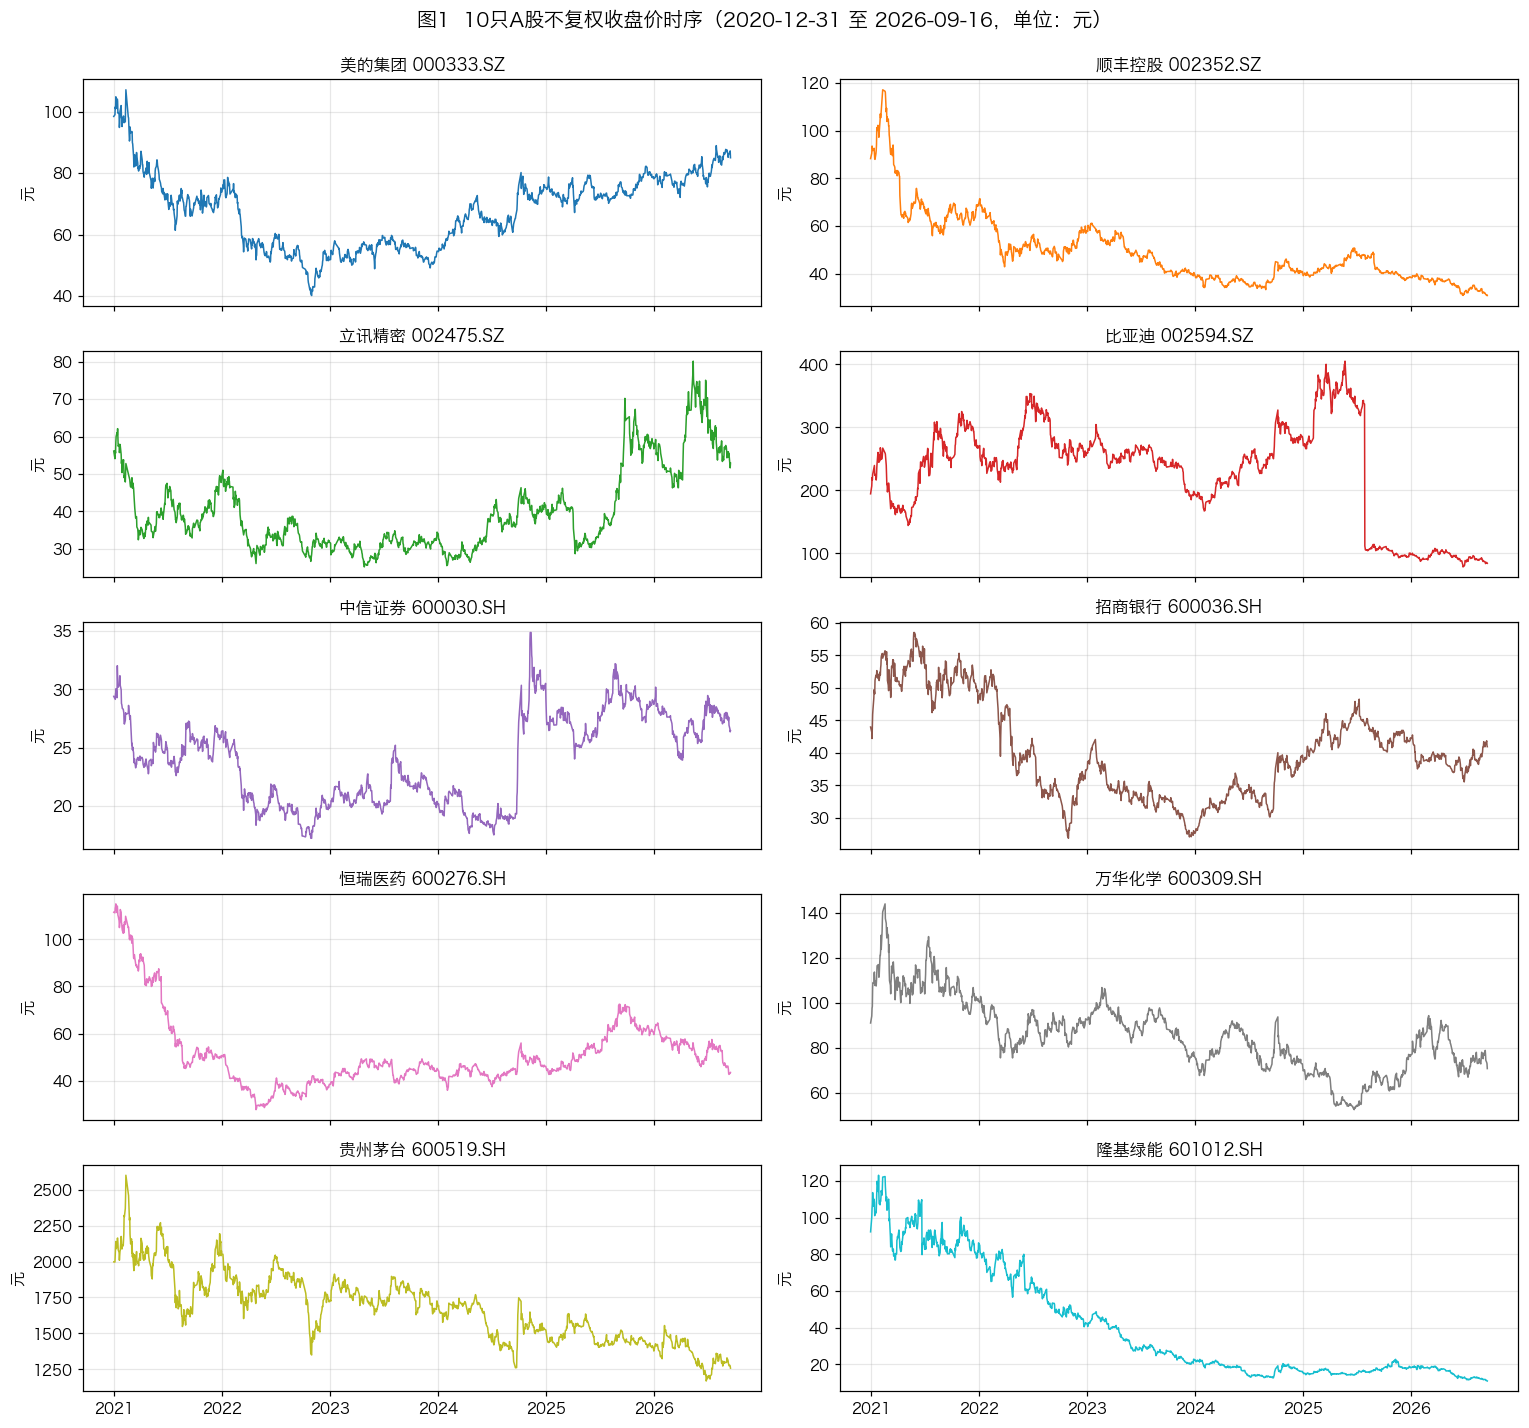

,股票,最低价,最高价,起点价,末价
stock_code,,,,,
000333.SZ,美的集团,40.18,107.11,98.44,85.00
002352.SZ,顺丰控股,30.75,117.10,88.23,30.75
002475.SZ,立讯精密,25.15,80.15,56.12,52.89
002594.SZ,比亚迪,78.20,405.00,194.30,83.96
600030.SH,中信证券,17.21,34.88,29.40,26.45
600036.SH,招商银行,26.82,58.50,43.95,40.92
600276.SH,恒瑞医药,27.74,115.00,111.46,43.52
600309.SH,万华化学,52.53,143.98,91.04,70.78
600519.SH,贵州茅台,1168.63,2601.00,1998.00,1258.00


In [9]:
# 图1：各股票不复权收盘价时序（分面）
fig, axes = plt.subplots(5, 2, figsize=(14, 13), sharex=True)
for ax, code in zip(axes.ravel(), order):
    sub = d[d["stock_code"] == code]
    ax.plot(sub["date"], sub["close_unadjusted"], color=colors[code], linewidth=1)
    ax.set_title(f"{names[code]} {code}", fontsize=11)
    ax.set_ylabel("元")
    ax.grid(alpha=0.3)
axes[0, 0].xaxis.set_major_locator(mdates.YearLocator())
axes[0, 0].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
fig.suptitle("图1  10只A股不复权收盘价时序（2020-12-31 至 2026-09-16，单位：元）",
             fontsize=13, y=0.995)
fig.tight_layout()
plt.show()

# 价格区间表
display(d.groupby("stock_code").agg(
    股票=("stock_name", "first"), 最低价=("close_unadjusted", "min"), 最高价=("close_unadjusted", "max"),
    起点价=("close_unadjusted", "first"), 末价=("close_unadjusted", "last")
).reindex(order))

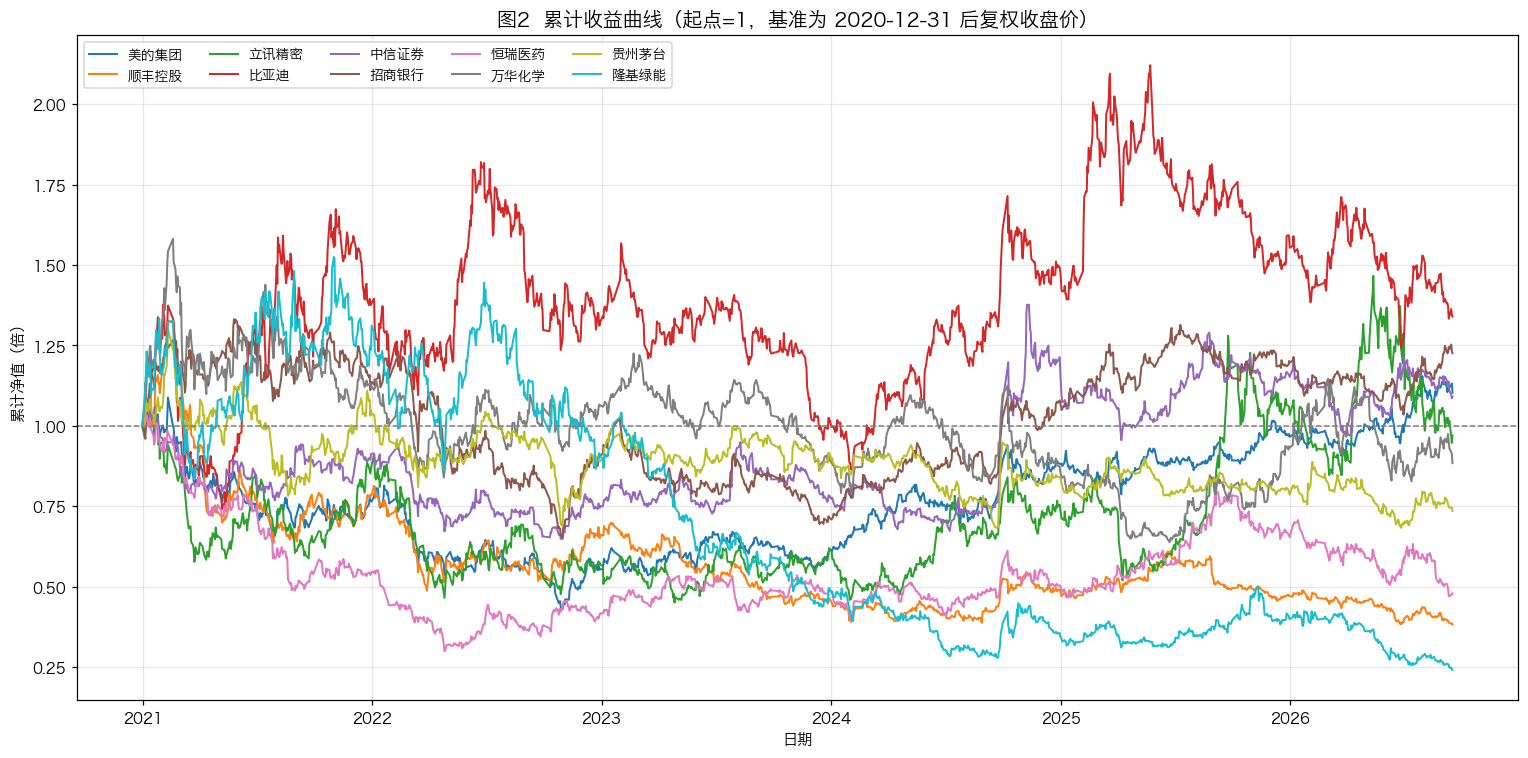

,stock_code,stock_name,净值,累计收益率
5536,002594.SZ,比亚迪,1.3399,0.3399
8300,600036.SH,招商银行,1.2259,0.2259
1384,000333.SZ,美的集团,1.1031,0.1031
6915,600030.SH,中信证券,1.0900,0.0900
4151,002475.SZ,立讯精密,0.9699,-0.0301
11070,600309.SH,万华化学,0.8841,-0.1159
12455,600519.SH,贵州茅台,0.7353,-0.2647
9685,600276.SH,恒瑞医药,0.4792,-0.5208
2766,002352.SZ,顺丰控股,0.3824,-0.6176
13840,601012.SH,隆基绿能,0.2412,-0.7588


净值大于1的股票数: 4  净值小于1的股票数: 6


,起点不复权价,末不复权价,不复权涨跌,净值,后复权累计 / 不复权累计
stock_code,,,,,
000333.SZ,98.44,85.00,-0.1365,1.1031,1.2775
002352.SZ,88.23,30.75,-0.6515,0.3824,1.0972
002475.SZ,56.12,52.89,-0.0576,0.9699,1.0291
002594.SZ,194.30,83.96,-0.5679,1.3399,3.1007
600030.SH,29.40,26.45,-0.1003,1.0900,1.2116
600036.SH,43.95,40.92,-0.0689,1.2259,1.3166
600276.SH,111.46,43.52,-0.6095,0.4792,1.2272
600309.SH,91.04,70.78,-0.2225,0.8841,1.1371
600519.SH,1998.00,1258.00,-0.3704,0.7353,1.1679


In [10]:
# 图2：起点为 1 的累计收益曲线（以 2020-12-31 后复权价为基准）
base_price = d.loc[d["date"] == "2020-12-31"].set_index("stock_code")["close_hfq"]
nav = d.copy()
nav["净值"] = nav["close_hfq"] / nav["stock_code"].map(base_price)

fig, ax = plt.subplots(figsize=(14, 7))
for code in order:
    sub = nav[nav["stock_code"] == code]
    ax.plot(sub["date"], sub["净值"], label=f"{names[code]}", color=colors[code], linewidth=1.3)
ax.axhline(1.0, color="gray", linestyle="--", linewidth=1)
ax.set_title("图2  累计收益曲线（起点=1，基准为 2020-12-31 后复权收盘价）", fontsize=13)
ax.set_xlabel("日期")
ax.set_ylabel("累计净值（倍）")
ax.legend(ncol=5, fontsize=9, loc="upper left")
ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()

# 期末累计净值排序
end_nav = nav.loc[nav["date"] == nav["date"].max(), ["stock_code", "stock_name", "净值"]]
end_nav = end_nav.assign(累计收益率=lambda x: x["净值"] - 1).sort_values("净值", ascending=False)
display(end_nav.assign(**{"净值": lambda x: x["净值"].round(4), "累计收益率": lambda x: x["累计收益率"].round(4)}))
print("净值大于1的股票数:", int((end_nav["净值"] > 1).sum()),
      " 净值小于1的股票数:", int((end_nav["净值"] < 1).sum()))

# 不复权价涨跌与后复权净值的对比：说明为什么不能用不复权价判断收益
compare = d.groupby("stock_code").agg(起点不复权价=("close_unadjusted", "first"), 末不复权价=("close_unadjusted", "last"))
compare["不复权涨跌"] = compare["末不复权价"] / compare["起点不复权价"] - 1
compare = compare.join(end_nav.set_index("stock_code")["净值"])
compare["后复权累计 / 不复权累计"] = compare["净值"] / (1 + compare["不复权涨跌"])
display(compare.reindex(order).round(4))

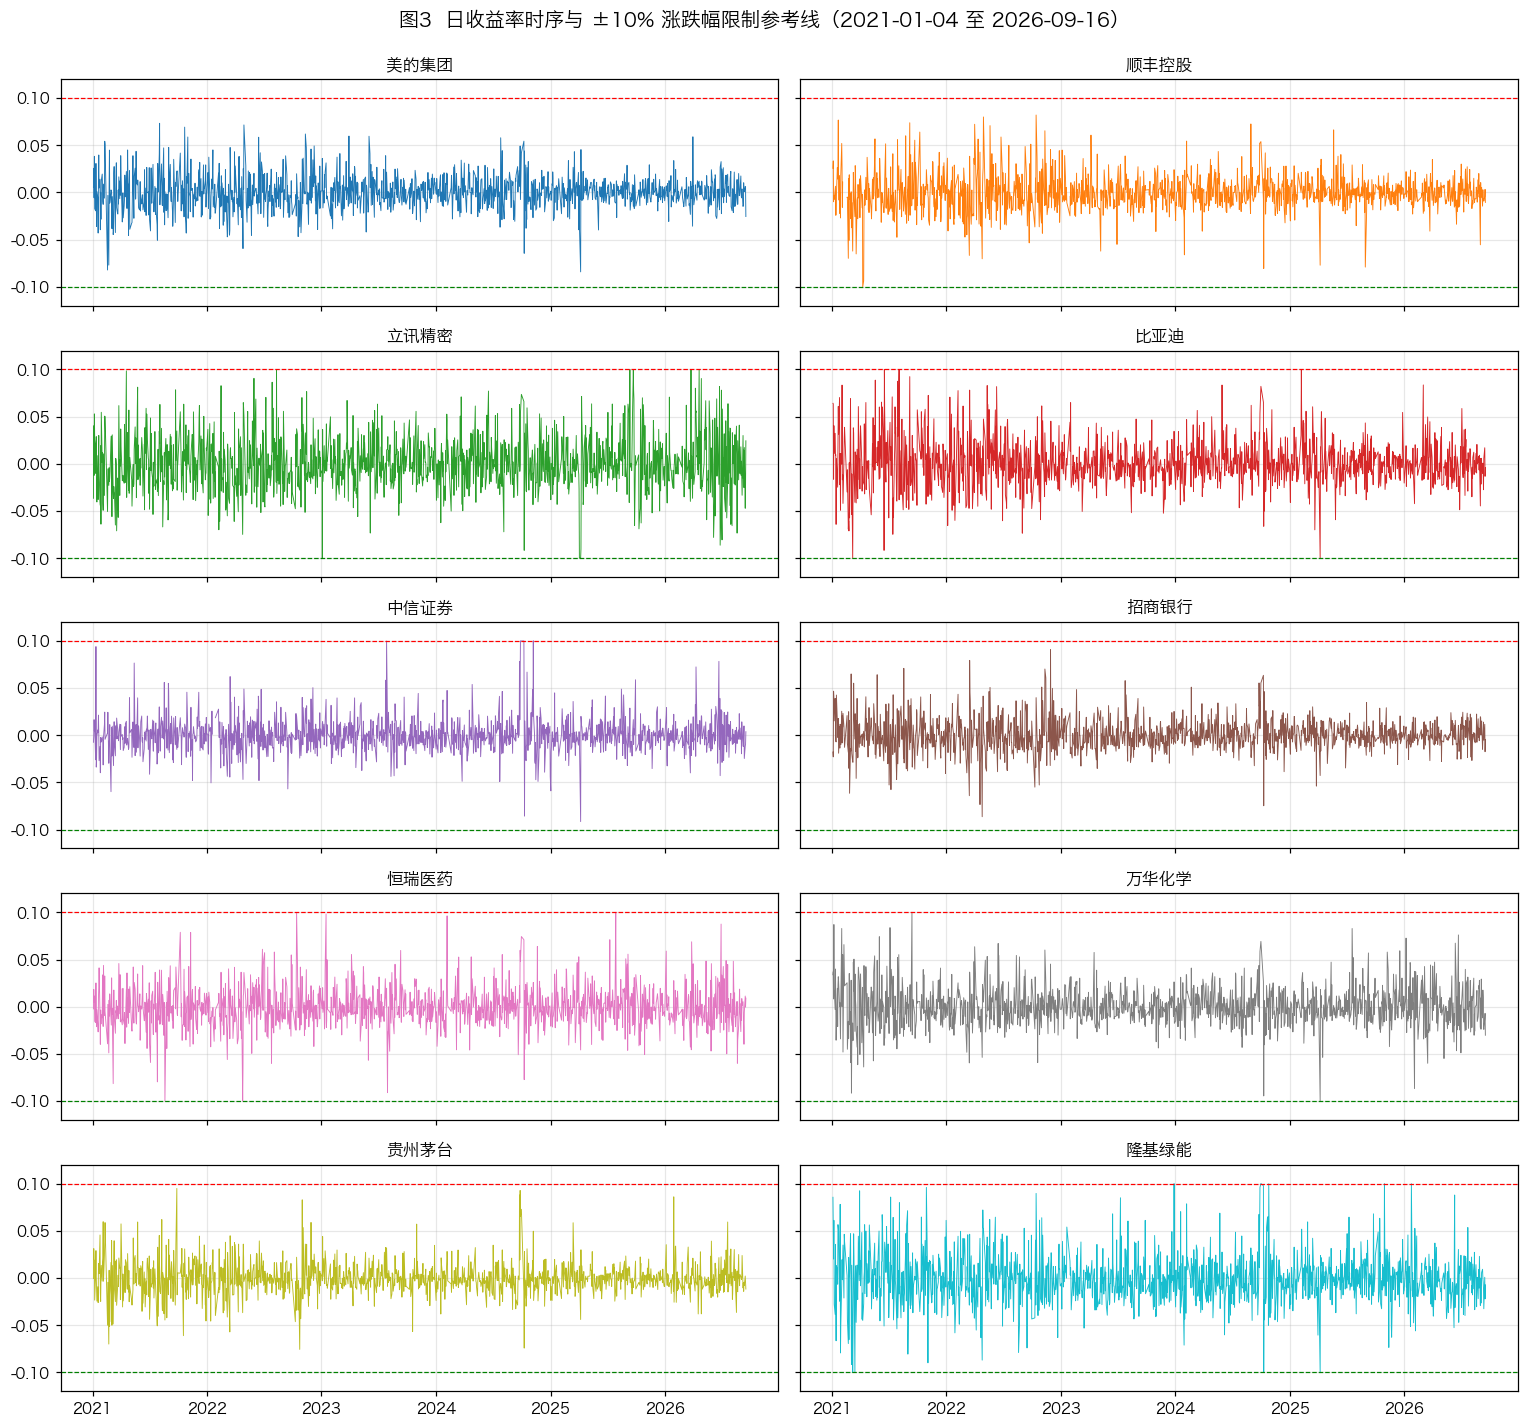

In [11]:
# 图3：日收益率时序（分面），叠加 ±10% 涨跌幅限制参考线
fig, axes = plt.subplots(5, 2, figsize=(14, 13), sharex=True, sharey=True)
for ax, code in zip(axes.ravel(), order):
    sub = d[(d["stock_code"] == code) & (d["date"] >= "2021-01-01")]
    ax.plot(sub["date"], sub["ret"], color=colors[code], linewidth=0.6)
    ax.axhline(0.10, color="red", linestyle="--", linewidth=0.8)
    ax.axhline(-0.10, color="green", linestyle="--", linewidth=0.8)
    ax.set_title(f"{names[code]}", fontsize=11)
    ax.set_ylim(-0.12, 0.12)
    ax.grid(alpha=0.3)
axes[0, 0].xaxis.set_major_locator(mdates.YearLocator())
axes[0, 0].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
fig.suptitle("图3  日收益率时序与 ±10% 涨跌幅限制参考线（2021-01-04 至 2026-09-16）",
             fontsize=13, y=0.995)
fig.tight_layout()
plt.show()

In [12]:
# 异常波动检查：分年统计与极值清单
ret_all = d.loc[d["date"] >= "2021-01-01", ["stock_code", "stock_name", "date", "ret"]].dropna(subset=["ret"])
by_year = ret_all.assign(年份=ret_all["date"].dt.year).groupby("年份").agg(
    有效观测数=("ret", "size"), 日收益标准差=("ret", "std"),
    最大单日涨幅=("ret", "max"), 最大单日跌幅=("ret", "min"),
)
# 阈值 9% 用于识别接近涨跌停的大幅波动观测
by_year["绝对值9pct以上个数"] = ret_all.assign(
    年份=ret_all["date"].dt.year).groupby("年份")["ret"].apply(lambda s: int((s.abs() >= 0.09).sum()))
display(by_year.round(4))

print("|r| >= 10% 的观测数:", int((ret_all["ret"].abs() >= 0.10).sum()),
      " |r| > 11% 的观测数:", int((ret_all["ret"].abs() > 0.11).sum()))
print("\n单日收益绝对值前 8 名:")
display(ret_all.reindex(ret_all["ret"].abs().sort_values(ascending=False).index)
        .head(8).assign(ret=lambda x: x["ret"].round(6)))

,有效观测数,日收益标准差,最大单日涨幅,最大单日跌幅,绝对值9pct以上个数
年份,,,,,
2021,2426,0.0266,0.1000,-0.1001,19
2022,2413,0.0238,0.1000,-0.1000,5
2023,2420,0.0171,0.1001,-0.0999,5
2024,2420,0.0209,0.1003,-0.1001,13
2025,2430,0.0185,0.1000,-0.1002,12
2026,1720,0.0203,0.1001,-0.0868,4


|r| >= 10% 的观测数: 22  |r| > 11% 的观测数: 0

单日收益绝对值前 8 名:


,stock_code,stock_name,date,ret
13364,601012.SH,隆基绿能,2024-09-30,0.100257
13486,601012.SH,隆基绿能,2025-04-07,-0.100244
13182,601012.SH,隆基绿能,2023-12-28,0.100119
6462,600030.SH,中信证券,2024-11-07,0.100110
13366,601012.SH,隆基绿能,2024-10-09,-0.100108
4048,002475.SZ,立讯精密,2026-04-20,0.100084
4193,002594.SZ,比亚迪,2021-03-08,-0.100060
6438,600030.SH,中信证券,2024-09-27,0.100048


### Step 3：Markdown结果解读

图1显示，10只股票的**不复权**价格水平差异极大：贵州茅台在1,168.63—2,601元之间波动，隆基绿能从最高123元跌到11元，比亚迪从194.30元降到83.96元。这张图只用于观察价格水平与走势，不能据此判断盈亏——送转股和现金分红会造成价格机械下调。

图2以2020-12-31的后复权收盘价为基准（净值=1）重算累计表现，结论与图1明显不同：截至2026-09-16，10只股票中**4只净值大于1、6只小于1**。比亚迪最高，累计净值1.3399（+33.99%）；招商银行1.2259、美的集团1.1031、中信证券1.0900次之；立讯精密0.9699接近持平；万华化学0.8841、贵州茅台0.7353、恒瑞医药0.4792、顺丰控股0.3824下跌；隆基绿能最低，仅0.2412，5年多累计亏损约75.9%。首尾差距接近5.6倍（1.3399 对 0.2412），分化极其悬殊。

比亚迪是最能说明复权必要性的例子：不复权价下跌56.8%，按后复权价计算的净值却上涨34.0%，两者相差约3.1倍，差额来自期间的送转股与现金分红。若只看不复权价，会把一只上涨的股票误判为大幅亏损。这也印证了第1节的口径设定：后复权价只是连续收益的尺度，不代表当时可成交的价格，但只有它才能用于计算收益。

图3显示，各股票日收益基本落在±10%以内。分年统计进一步给出波动的时间分布：日收益标准差2021年最高（0.0266），2023年最低（0.0171），2024年回升至0.0209；日收益绝对值达到9%以上的观测，2021年有19个、2024年13个、2025年12个，而2022年和2023年各只有5个。极端波动明显集中在2021年与2024—2025年两段，具有时间聚集特征。单日极值前三名均来自隆基绿能：2024-09-30 +10.03%、2025-04-07 −10.02%、2023-12-28 +10.01%；该股同时是累计净值最低的一只，"收益最低、波动最大"两项特征相互一致。

需要说明的是，这些时点与市场事件（2021年春节后核心资产调整、2024年9月政策转向、2025年4月外部关税冲击）在时间上吻合，但本节图形只能说明波动在何时聚集，**不能证明因果关系**；要确认具体成因还需对照公司公告与宏观信息，这超出本题数据范围。

核心发现：

- 4只上涨、6只下跌，首尾累计净值相差约5.6倍，样本期内分化极大；
- 不复权价与后复权净值可能方向相反（比亚迪：−56.8% 对 +34.0%），收益判断必须使用后复权价；
- 日收益全部落在主板±10%涨跌幅限制内，|r| > 11% 的观测为0，未发现越界或单位错误；
- 波动具有明显时间聚集：2021年与2024—2025年是两段高波动期，隆基绿能是单日极值最集中的股票。

## 4. 20日滚动年化波动率

### Step 1：Markdown分析说明

本节要回答三个问题：第一，各股票的波动水平有多高、谁最稳定；第二，波动在时间上如何变化、是否与市场事件同步；第三，把10只股票放在一起后，组合的波动为什么明显低于个股。

计算口径严格按作业要求：年化波动率等于日收益率样本标准差乘以 $\sqrt{252}$；滚动窗口包含20个交易日；不足20个观测时不计算。在此基础上补充一条处理规则：**若窗口内含有第2节剔除的跨期收益，则该窗口不计算**。原因是这类窗口的价格变化跨越了停牌期，把它混入20日标准差会高估真实的日内波动。顺丰控股和中信证券因此各少20个窗口，合计40个，代价可量化。

分析要点与检查事项：

- 水平比较：滚动年化波动率的均值、中位数与期末值，横向排序；
- 时点比较：各股票波动率峰值及其出现日期，识别共同的波动高发期；
- 分散化：把10只股票按等权合成组合，比较组合波动率与个股波动率均值；
- 收益与风险：结合第3节的累计净值，观察高波动是否对应高收益；
- 单位统一用百分比，图表标明标题、日期范围、单位与图例。

### Step 2：代码与实际输出

下面先计算各股票的20日滚动年化波动率，再绘制个股波动率时序、组合与个股均值对比，最后给出汇总统计与峰值时点。

In [13]:
# 20日滚动年化波动率：日收益样本标准差 × sqrt(252)，窗口不足 20 个观测时不计算
import numpy as np

ANN = np.sqrt(252)
d["vol20"] = d.groupby("stock_code", group_keys=False)["ret"].apply(
    lambda s: s.rolling(20, min_periods=20).std() * ANN
)
vol = d.loc[d["date"] >= "2021-01-01"]

summary = vol.groupby("stock_code").agg(
    简称=("stock_name", "first"),
    滚动均值=("vol20", "mean"), 滚动中位=("vol20", "median"),
    滚动最大=("vol20", "max"), 滚动最小=("vol20", "min"),
    期末值=("vol20", "last"), 有效窗口数=("vol20", "count"),
    全期年化=("ret", lambda s: s.std() * ANN),
)
# 峰值出现日期
peak_date = vol.loc[vol.groupby("stock_code")["vol20"].idxmax(), ["stock_code", "date"]].set_index("stock_code")["date"]
summary["峰值日期"] = peak_date
summary_pct = summary.assign(**{c: summary[c] * 100 for c in
                                ["滚动均值", "滚动中位", "滚动最大", "滚动最小", "期末值", "全期年化"]})
display(summary_pct.sort_values("全期年化", ascending=False).round(2))

# 因窗口内含跨期收益而无法计算的窗口数
expected = vol.groupby("stock_code")["ret"].apply(lambda s: max(len(s) - 19, 0))
lost = (expected - summary["有效窗口数"]).astype(int)
print("各股票预期窗口数与实际有效窗口数之差（跨期收益导致的窗口损失）:")
print(lost[lost > 0].to_string())
print("合计损失窗口数:", int(lost.sum()))

,简称,滚动均值,滚动中位,滚动最大,滚动最小,期末值,有效窗口数,全期年化,峰值日期
stock_code,,,,,,,,,
002475.SZ,立讯精密,44.14,42.30,85.40,15.78,37.42,1365,45.79,2026-07-03
601012.SH,隆基绿能,40.09,36.60,95.75,16.34,22.71,1365,42.48,2024-10-30
002594.SZ,比亚迪,36.51,32.70,84.45,14.69,24.43,1365,39.11,2021-08-05
600276.SH,恒瑞医药,32.82,31.20,64.36,14.26,31.48,1365,33.98,2024-10-24
600309.SH,万华化学,31.07,28.17,72.18,11.33,30.55,1365,33.06,2021-03-05
002352.SZ,顺丰控股,27.99,25.57,59.83,10.78,24.11,1342,30.10,2022-04-29
600030.SH,中信证券,26.25,24.24,79.53,11.08,18.26,1339,28.35,2024-10-24
000333.SZ,美的集团,26.55,24.20,60.53,10.27,17.43,1365,28.24,2021-03-15
600519.SH,贵州茅台,25.04,22.22,70.56,8.36,16.90,1365,27.25,2024-10-18


各股票预期窗口数与实际有效窗口数之差（跨期收益导致的窗口损失）:
stock_code
002352.SZ    20
600030.SH    20
合计损失窗口数: 40


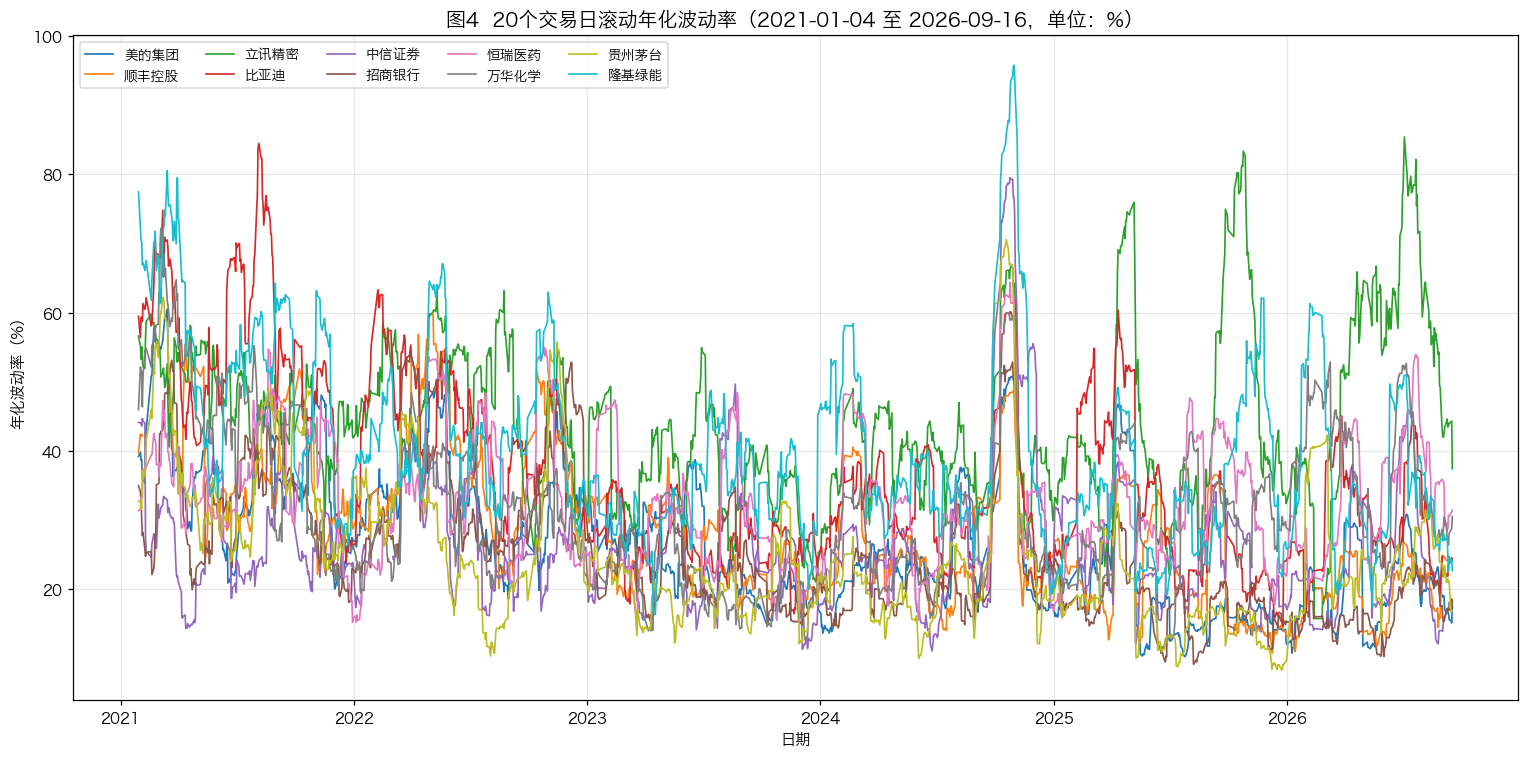

In [14]:
# 图4：各股票 20 日滚动年化波动率时序
fig, ax = plt.subplots(figsize=(14, 7))
for code in order:
    sub = vol[vol["stock_code"] == code]
    ax.plot(sub["date"], sub["vol20"] * 100, label=names[code], color=colors[code], linewidth=1.1)
ax.set_title("图4  20个交易日滚动年化波动率（2021-01-04 至 2026-09-16，单位：%）", fontsize=13)
ax.set_xlabel("日期")
ax.set_ylabel("年化波动率（%）")
ax.legend(ncol=5, fontsize=9, loc="upper left")
ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()

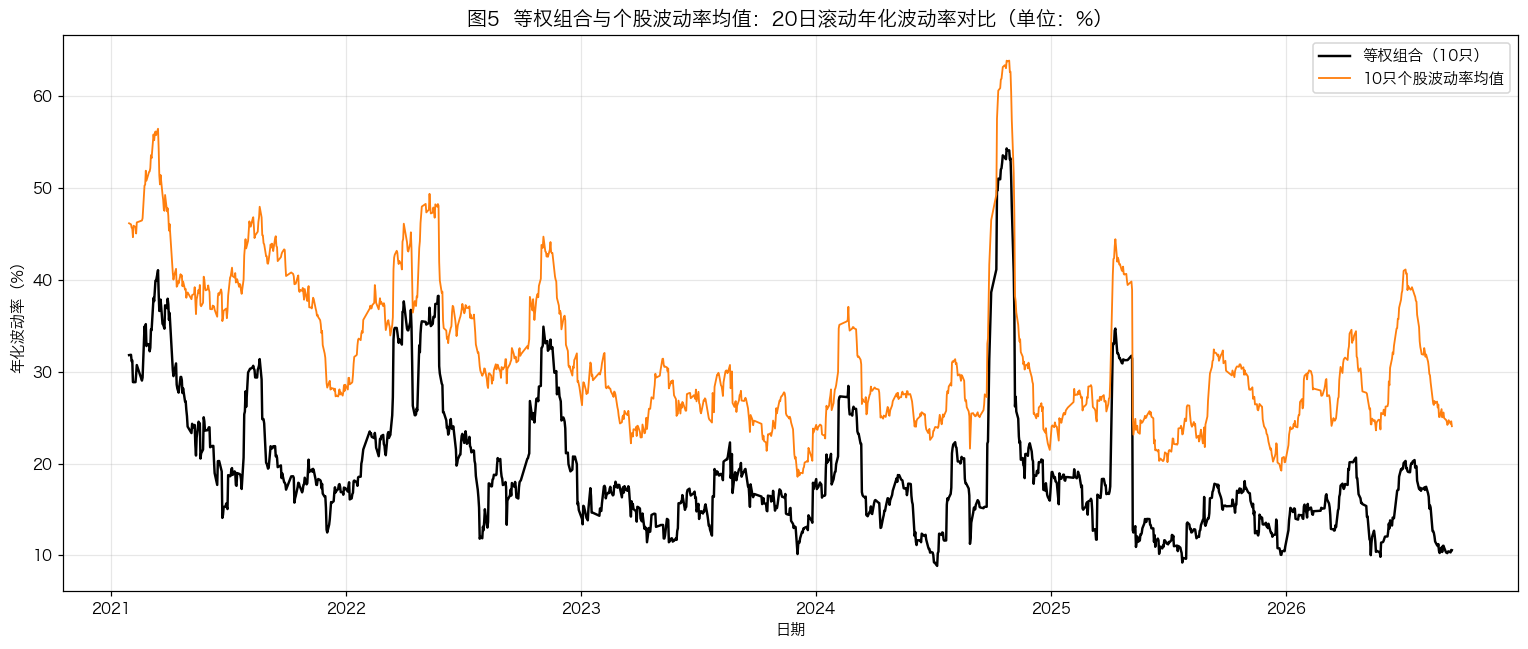

等权组合全期年化波动率(%): 20.7
个股全期年化波动率均值(%): 33.52
个股中最低的全期年化波动率(%): 26.82
组合波动率 / 个股均值: 0.618

等权组合滚动波动率最高的 10 个日期:


,年化波动率(%)
date,
2024-10-24,54.32
2024-10-28,54.12
2024-10-25,54.09
2024-10-18,53.57
2024-10-21,53.38
2024-10-30,53.25
2024-10-22,53.23
2024-10-23,53.15
2024-10-29,53.11


In [15]:
# 图5：等权组合的滚动波动率与个股波动率均值对比（分散化效应）
# 等权组合日收益：每日对各股票可用收益取平均（停牌日该股缺失，等价于在剩余股票间等权）
eq_ret = vol.groupby("date")["ret"].mean()
eq_vol = eq_ret.rolling(20, min_periods=20).std() * ANN
ind_avg_vol = vol.groupby("date")["vol20"].mean()

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(eq_vol.index, eq_vol * 100, label="等权组合（10只）", color="black", linewidth=1.6)
ax.plot(ind_avg_vol.index, ind_avg_vol * 100, label="10只个股波动率均值", color="tab:orange", linewidth=1.2)
ax.set_title("图5  等权组合与个股波动率均值：20日滚动年化波动率对比（单位：%）", fontsize=13)
ax.set_xlabel("日期")
ax.set_ylabel("年化波动率（%）")
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()

print("等权组合全期年化波动率(%):", round(float(eq_ret.std() * ANN * 100), 2))
print("个股全期年化波动率均值(%):", round(float(summary["全期年化"].mean() * 100), 2))
print("个股中最低的全期年化波动率(%):", round(float(summary["全期年化"].min() * 100), 2))
print("组合波动率 / 个股均值:", round(float(eq_ret.std() * ANN / summary["全期年化"].mean()), 3))
print("\n等权组合滚动波动率最高的 10 个日期:")
display((eq_vol * 100).sort_values(ascending=False).head(10).round(2).to_frame("年化波动率(%)"))

### Step 3：Markdown结果解读

波动水平的分化很明显。按全期年化波动率排序，立讯精密最高（45.79%），隆基绿能42.48%、比亚迪39.11%紧随其后；恒瑞医药33.98%、万华化学33.06%居中；招商银行最低（26.82%），贵州茅台27.25%、美的集团28.24%、中信证券28.35%次之。滚动窗口的均值与中位数给出同样的排序，说明这不是少数极端日造成的假象，而是各股票长期的波动特征。最高与最低相差约1.7倍（45.79% 对 26.82%）。

波动的时点高度集中。个股波动率峰值中，隆基绿能95.75%出现在2024-10-30，中信证券79.53%与恒瑞医药64.36%都出现在2024-10-24，贵州茅台70.56%出现在2024-10-18；等权组合滚动波动率最高的10个日期全部落在2024-10-17至10-30之间。这说明2024年10月是全市场性的高波动期，不是个别股票的特殊事件。另一段高波动期在2021年一季度：万华化学72.18%（2021-03-05）与美的集团60.53%（2021-03-15）的峰值都出现在这一时期。此外立讯精密85.40%（2026-07-03）与比亚迪84.45%（2021-08-05）的峰值更偏个股自身因素。这些时点与市场事件时间吻合，但本节只能说明波动在何时聚集，不能据此认定因果。

图5给出了本节最有价值的一个证据：**等权组合的全期年化波动率为20.70%，不但低于10只个股的均值33.52%，甚至低于个股中波动最小的一只（招商银行26.82%）**，组合波动率仅为个股均值的0.618倍。原因是各股票的日收益不完全同步，涨跌相互抵消，这正是分散投资降低风险的作用；也要注意，这里的"降低"指的是波动率这一风险度量，不等于组合不会亏损。

把第3节的累计净值与本节波动率放在一起看：隆基绿能波动第二高（42.48%）而累计净值最低（0.2412），招商银行波动最低（26.82%）而净值第二高（1.2259），两者方向相反；但比亚迪是个反例——波动第三高（39.11%）却取得最高净值（1.3399）。因此在这个10只股票的样本里，**高波动并没有系统性地换来高收益**，收益与风险的关系更接近"部分股票承担了高波动却没有相应回报"。这只是事后样本的描述性观察：股票池是按行业与商业模式事先选定的，不是按风险因子构建的，且只有10只样本，不能据此推断风险与收益的一般关系，更不涉及因果。

处理规则的代价也已经量化：因窗口内含跨期收益而不计算的窗口共40个（顺丰控股、中信证券各20个），占理论窗口数的0.3%，对整体结论没有实质影响。

核心发现：

- 波动水平分化1.7倍：立讯精密最高45.79%，招商银行最低26.82%；
- 波动有明显的时间聚集，2024年10月是全市场共同的高波动期，2021年一季度是次高；
- 等权组合年化波动率20.70%，低于任何单只个股，分散化把波动降到个股均值的0.617倍；
- 高波动在本样本中并未对应高收益，隆基绿能是"高波动、低收益"的典型。

## 5. 描述统计与异常收益检查

### Step 1：Markdown分析说明

本节要回答三个问题：第一，10只股票日收益率的分布形态如何；第二，哪些观测算异常值、它们是否合理；第三，如果把这些异常观测删掉或缩尾，主要结果会不会变。

先说明分工：重复记录、缺失值、单位、日期和分母有效性已在第2节核对完毕，本节聚焦**离群值与分布形态**。异常值的作用按作业要求理解为"定位需要解释的记录"，不是"自动生成删除名单"；检查离群值是必做项，缩尾不是必做项。

因此本节的做法是：先给出完整描述统计，再用两种口径识别异常，最后做一次处理前后的敏感性比较，用数字说明"删或不删"对结论的影响，再决定保留。

判定口径与检查事项：

- 描述统计：有效观测数、均值、标准差、最小值、中位数、最大值、偏度、超额峰度，逐只股票给出；
- 异常口径一：个股内部标准化，$|z|>4$、$>5$、$>6$，用于看极端观测有多少；
- 异常口径二：绝对值达到9.5%，即接近主板±10%涨跌幅限制，用于看涨跌停级别的观测有多少；
- 分布形态：偏度与超额峰度是否为正，判断是否存在尖峰厚尾；
- 敏感性：剔除绝对值9.5%以上的观测后，比较各股票均值与标准差的变化；
- 决策依据：若处理后主要统计量与股票间排序基本不变，就保留原观测，只作解释，不做缩尾或删除。

### Step 2：代码与实际输出

下面先给出按作业要求逐项列明的描述统计，再用箱线图比较10只股票的分布与离群点，最后识别异常观测并做处理前后的敏感性比较。

In [16]:
# 描述统计：作业要求逐项列明的 8 个统计量
ret_stats = d.loc[d["date"] >= "2021-01-01"].dropna(subset=["ret"])
desc = ret_stats.groupby("stock_code").agg(
    简称=("stock_name", "first"),
    有效观测数=("ret", "size"),
    均值=("ret", "mean"),
    标准差=("ret", "std"),
    最小值=("ret", "min"),
    中位数=("ret", "median"),
    最大值=("ret", "max"),
    偏度=("ret", "skew"),
    超额峰度=("ret", lambda s: s.kurt()),   # pandas 的 kurt 已是超额峰度（减 3）
)
display(desc.round({c: 6 for c in ["均值", "标准差", "最小值", "中位数", "最大值"]}
                   | {c: 4 for c in ["偏度", "超额峰度"]}))

print("全部股票合计有效观测数:", len(ret_stats))
print("池化日收益均值:", round(float(ret_stats["ret"].mean()), 6),
      " 池化日收益标准差:", round(float(ret_stats["ret"].std()), 6))
print("池化偏度:", round(float(ret_stats["ret"].skew()), 4),
      " 池化超额峰度:", round(float(ret_stats["ret"].kurt()), 4))
print("正收益观测占比:", round(float((ret_stats["ret"] > 0).mean()), 4))

,简称,有效观测数,均值,标准差,最小值,中位数,最大值,偏度,超额峰度
stock_code,,,,,,,,,
000333.SZ,美的集团,1384,0.000229,0.017788,-0.084227,-0.000145,0.073246,0.1419,1.9975
002352.SZ,顺丰控股,1380,-0.000586,0.018960,-0.100000,-0.001513,0.082022,0.1573,3.4298
002475.SZ,立讯精密,1384,0.000392,0.028845,-0.099944,-0.002455,0.100084,0.3120,0.9534
002594.SZ,比亚迪,1384,0.000513,0.024639,-0.100060,-0.001286,0.100018,0.4710,2.0882
600030.SH,中信证券,1377,0.000223,0.017856,-0.091537,-0.000535,0.100110,0.9409,6.0145
600036.SH,招商银行,1384,0.000289,0.016895,-0.086343,-0.000699,0.090727,0.2991,3.2992
600276.SH,恒瑞医药,1384,-0.000303,0.021403,-0.099999,-0.001571,0.100001,0.3718,2.9000
600309.SH,万华化学,1384,0.000127,0.020829,-0.099938,-0.001277,0.100046,0.3565,2.5745
600519.SH,贵州茅台,1384,-0.000076,0.017167,-0.075567,-0.000951,0.095041,0.5843,4.3322


全部股票合计有效观测数: 13829
池化日收益均值: 1.4e-05  池化日收益标准差: 0.021497
池化偏度: 0.409  池化超额峰度: 2.9883
正收益观测占比: 0.4644


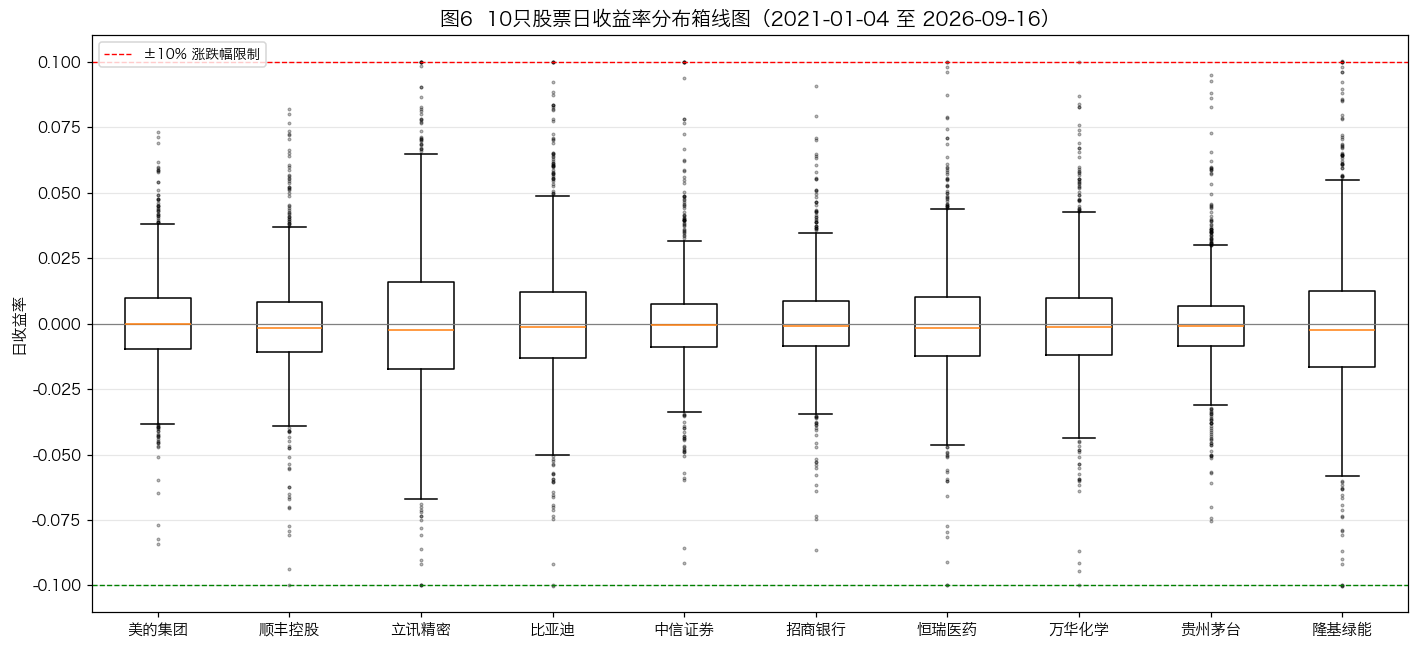

In [17]:
# 图6：10只股票日收益率箱线图（对比分布与离群点）
fig, ax = plt.subplots(figsize=(13, 6))
data = [ret_stats.loc[ret_stats["stock_code"] == c, "ret"].to_numpy() for c in order]
bp = ax.boxplot(data, tick_labels=[names[c] for c in order], showfliers=True,
                flierprops={"marker": ".", "markersize": 3, "alpha": 0.4})
ax.axhline(0.10, color="red", linestyle="--", linewidth=0.9, label="±10% 涨跌幅限制")
ax.axhline(-0.10, color="green", linestyle="--", linewidth=0.9)
ax.axhline(0, color="gray", linewidth=0.8)
ax.set_title("图6  10只股票日收益率分布箱线图（2021-01-04 至 2026-09-16）", fontsize=13)
ax.set_ylabel("日收益率")
ax.legend(fontsize=9)
ax.grid(alpha=0.3, axis="y")
fig.tight_layout()
plt.show()

In [18]:
# 异常观测识别：个股内标准化 z 值 + 接近涨跌停的绝对阈值
ret_stats = ret_stats.assign(
    z=ret_stats.groupby("stock_code")["ret"].transform(lambda s: (s - s.mean()) / s.std())
)
for k in [4, 5, 6]:
    n_k = int((ret_stats["z"].abs() > k).sum())
    print(f"|z| > {k} 的观测数: {n_k}（占有效样本 {n_k / len(ret_stats) * 100:.3f}%）")
print("|r| >= 9% 的观测数:", int((ret_stats["ret"].abs() >= 0.09).sum()))
print("|r| >= 9.5% 的观测数:", int((ret_stats["ret"].abs() >= 0.095).sum()))

print("\n绝对值最大的 10 个观测及其 z 值:")
display(ret_stats.reindex(ret_stats["ret"].abs().sort_values(ascending=False).index)
        .head(10)[["stock_code", "stock_name", "date", "ret", "z"]].round(4))

|z| > 4 的观测数: 62（占有效样本 0.448%）
|z| > 5 的观测数: 14（占有效样本 0.101%）
|z| > 6 的观测数: 0（占有效样本 0.000%）
|r| >= 9% 的观测数: 58
|r| >= 9.5% 的观测数: 42

绝对值最大的 10 个观测及其 z 值:


,stock_code,stock_name,date,ret,z
13364,601012.SH,隆基绿能,2024-09-30,0.1003,3.7720
13486,601012.SH,隆基绿能,2025-04-07,-0.1002,-3.7213
13182,601012.SH,隆基绿能,2023-12-28,0.1001,3.7668
6462,600030.SH,中信证券,2024-11-07,0.1001,5.5940
13366,601012.SH,隆基绿能,2024-10-09,-0.1001,-3.7162
4048,002475.SZ,立讯精密,2026-04-20,0.1001,3.4561
4193,002594.SZ,比亚迪,2021-03-08,-0.1001,-4.0818
6438,600030.SH,中信证券,2024-09-27,0.1000,5.5906
9857,600309.SH,万华化学,2021-09-13,0.1000,4.7972
13683,601012.SH,隆基绿能,2026-01-23,0.1000,3.7640


In [19]:
# 敏感性比较：剔除绝对值 9.5% 以上的观测后，均值与标准差的变化
THRESH = 0.095
kept = ret_stats[ret_stats["ret"].abs() < THRESH]
comp = pd.DataFrame({
    "有效观测数(原)": ret_stats.groupby("stock_code")["ret"].size(),
    "剔除观测数": ret_stats.groupby("stock_code")["ret"].size() - kept.groupby("stock_code")["ret"].size(),
    "均值(原)": ret_stats.groupby("stock_code")["ret"].mean(),
    "均值(剔除后)": kept.groupby("stock_code")["ret"].mean(),
    "标准差(原)": ret_stats.groupby("stock_code")["ret"].std(),
    "标准差(剔除后)": kept.groupby("stock_code")["ret"].std(),
})
comp["均值变化(基点)"] = (comp["均值(剔除后)"] - comp["均值(原)"]) * 1e4
comp["标准差变化(百分点)"] = (comp["标准差(剔除后)"] - comp["标准差(原)"]) * 100
display(comp.round(6))
print("合计剔除观测数:", int(comp["剔除观测数"].sum()))
print("均值变化的最大绝对值(基点):", round(float(comp["均值变化(基点)"].abs().max()), 2))
print("标准差变化的最大绝对值(百分点):", round(float(comp["标准差变化(百分点)"].abs().max()), 4))
print("波动率排序是否改变:",
      list(comp["标准差(原)"].sort_values(ascending=False).index) !=
      list(comp["标准差(剔除后)"].sort_values(ascending=False).index))

,有效观测数(原),剔除观测数,均值(原),均值(剔除后),标准差(原),标准差(剔除后),均值变化(基点),标准差变化(百分点)
stock_code,,,,,,,,
000333.SZ,1384,0,0.000229,0.000229,0.017788,0.017788,0.000000,0.000000
002352.SZ,1380,1,-0.000586,-0.000514,0.018960,0.018776,0.720915,-0.018329
002475.SZ,1384,9,0.000392,0.000177,0.028845,0.027791,-2.147602,-0.105387
002594.SZ,1384,6,0.000513,0.000370,0.024639,0.023796,-1.428718,-0.084270
600030.SH,1377,5,0.000223,-0.000141,0.017856,0.016839,-3.635713,-0.101648
600036.SH,1384,0,0.000289,0.000289,0.016895,0.016895,0.000000,0.000000
600276.SH,1384,6,-0.000303,-0.000446,0.021403,0.020426,-1.424756,-0.097724
600309.SH,1384,2,0.000127,0.000127,0.020829,0.020493,0.001055,-0.033521
600519.SH,1384,1,-0.000076,-0.000144,0.017167,0.016982,-0.687757,-0.018560


合计剔除观测数: 42
均值变化的最大绝对值(基点): 3.64
标准差变化的最大绝对值(百分点): 0.1548
波动率排序是否改变: True


### Step 3：Markdown结果解读

描述统计显示，10只股票的有效观测数为1,377—1,384个（顺丰控股1,380、中信证券1,377，因停牌与跨期剔除少于其余8只）。日均收益最高的是比亚迪（+0.0513%），最低的是隆基绿能（−0.0671%）与顺丰控股（−0.0586%）；贵州茅台（−0.0076%）与恒瑞医药（−0.0303%）也为负。日收益标准差最高的是立讯精密（2.885%），最低的是招商银行（1.690%），与第4节的年化波动率排序完全一致——两项指标互为印证，不是两套口径各说各话。

最小值和最大值贴近但不超出±10%：多数股票的最大值与最小值落在−10%至+10%之间，只有美的集团（−8.42%至+7.32%）、招商银行（−8.63%至+9.07%）和贵州茅台（−7.56%至+9.50%）在样本期内没有触及涨跌停。这与10只股票均为主板、日涨跌幅限制±10%的制度约束相符。

分布形态上，10只股票的**偏度全部为正**（0.14—0.94），**超额峰度全部为正**（0.95—6.01），池化后偏度0.409、超额峰度2.988。正的偏度说明右侧极端收益略多于左侧；正的超额峰度说明分布比正态更"尖峰厚尾"，极端日的出现频率高于正态分布预期。中信证券的超额峰度最高（6.01），与其在2024年9—10月券商行情中的连续大幅波动一致；顺丰控股（3.43）、招商银行（3.30）、贵州茅台（4.33）次之。这也意味着用正态假设做风险估计会低估尾部风险。池化样本中正收益占比46.44%，略低于一半。

异常观测的识别结果是：按个股内标准化口径，$|z|>4$ 的观测62个（占0.448%），$|z|>5$ 的14个（0.101%），**$|z|>6$ 的0个**；按绝对阈值，日收益绝对值达到9%的58个、达到9.5%的42个。也就是说，无论用哪种口径，极端观测的占比都在0.5%以内，且不存在与整体分布完全脱节的孤立点——最极端的观测也只到$|z|$约5，且它们的绝对值都紧贴10%的涨跌停线。

敏感性比较给出了处理依据：把绝对值9.5%以上的42个观测剔除后（隆基绿能12个、立讯精密9个、比亚迪与恒瑞医药各6个、中信证券5个、万华化学2个、顺丰控股与贵州茅台各1个，美的集团与招商银行为0），标准差变化最大的是隆基绿能（−0.155个百分点，相当于原值的5.8%）与立讯精密（−0.105个百分点）；均值变化最大的是中信证券（−3.64个基点），**其日均收益由+0.0223%转为−0.0141%，说明该股的日均收益主要由少数大幅上涨日贡献**，这一点值得单独留意。

位次上也要如实说明：剔除后标准差排序在两对相邻股票之间发生互换——中信证券与美的集团（原标准差相差0.7个基点）、恒瑞医药与万华化学（相差5.7个基点）。两端的排序不变，立讯精密仍最高、招商银行仍最低；发生互换的两对本身差距就在统计上难以区分的水平，且剔除与否都只影响相邻位次，不改变"高波动组—中波动组—低波动组"的整体梯队。综合看，处理前后的差异集中在个别股票的相邻位次与个别均值符号，**幅度不超过原标准差的6%**。

据此作出处理决定：**不删除、不缩尾，保留全部13,829个有效观测**，只对异常值作出解释。理由是这些观测全部落在涨跌停制度允许的范围内，很可能是真实的市场价格变动而非录入错误；既然剔除与否不改变排序与结论，就没有理由为了减少"不好看的数字"而损失真实信息。需要说明的是，正的超额峰度意味着后续若用正态假设计算风险指标（如在险价值），会低估尾部风险。

核心发现：

- 日均收益最高为比亚迪+0.0513%，最低为隆基绿能−0.0671%；日波动最大为立讯精密2.885%，最小为招商银行1.690%，与第4节年化口径一致；
- 10只股票偏度与超额峰度均为正，池化超额峰度2.988，分布尖峰厚尾，正态假设会低估尾部风险；
- 极端观测占比极低（|z|>5 仅0.101%，|z|>6 为0），且全部紧贴±10%涨跌停线，未见技术错误；
- 剔除42个极端观测后标准差变化不超过原值的6%，仅两对相邻位次互换，故保留全部观测，不做缩尾或删除。

## 6. 日收益率Pearson相关性

### Step 1：Markdown分析说明

本节要回答三个问题：第一，10只股票的日收益率彼此相关到什么程度；第二，同行业的股票是否更相关；第三，相关性结构如何解释第4节观察到的分散化效果。

先把三个口径交代清楚。**日期对齐**采用成对完整观测（pairwise）：两只股票在同一天都有有效收益时才计入这一对的计算。**缺失处理**沿用第2节的规则——停牌日不生成收益、跨期收益置为缺失，两者都不填零，因此不同股票对的可用天数略有差别。**实际样本量**逐对报告：最少1,373天、最多1,384天。为检验对齐方式是否影响结论，本节同时给出共同样本口径（只保留10只股票都有收益的1,373天）的结果作对照。

分析要点与检查事项：

- 相关系数矩阵与热力图同时给出，矩阵看数值、热力图看结构；
- 报告45对组合的平均、最高与最低相关系数；
- 同行业检验：本样本中唯一同属一个CSMAR行业的两只股票是美的集团与隆基绿能（电气机械和器材制造业），剔除该对与金融板块对后剩43对作为对照；另把金融板块的招商银行与中信证券单独列出；
- 与第4节的分散化结果交叉验证：用平均相关系数推算等权组合波动率的理论值，与实际值对比；
- 相关系数只度量线性共动，不等于因果关系，也不区分"共同因子驱动"与"相互传染"。

### Step 2：代码与实际输出

下面先把收益率整理成"日期 × 股票"矩阵，再给出相关矩阵、热力图、成对样本量与同行业对照。

In [20]:
# 整理为 日期 × 股票 的日收益矩阵
ret_wide = d.loc[d["date"] >= "2021-01-01"].pivot(index="date", columns="stock_code", values="ret")
ret_wide = ret_wide.reindex(columns=order)
print("矩阵形状:", ret_wide.shape)
print("各股票有效收益观测数:")
print(ret_wide.notna().sum().to_string())

# 成对完整观测的相关系数矩阵（pairwise）
corr = ret_wide.corr(method="pearson")
display(corr.round(4))

矩阵形状: (1384, 10)
各股票有效收益观测数:
stock_code
000333.SZ    1384
002352.SZ    1380
002475.SZ    1384
002594.SZ    1384
600030.SH    1377
600036.SH    1384
600276.SH    1384
600309.SH    1384
600519.SH    1384
601012.SH    1384


stock_code,000333.SZ,002352.SZ,002475.SZ,002594.SZ,600030.SH,600036.SH,600276.SH,600309.SH,600519.SH,601012.SH
stock_code,,,,,,,,,,
000333.SZ,1.0000,0.3841,0.2260,0.2274,0.3607,0.4564,0.3111,0.3064,0.4542,0.1689
002352.SZ,0.3841,1.0000,0.2488,0.3037,0.3463,0.3260,0.3427,0.3818,0.4226,0.3187
002475.SZ,0.2260,0.2488,1.0000,0.3394,0.3031,0.1483,0.2575,0.2078,0.2357,0.2985
002594.SZ,0.2274,0.3037,0.3394,1.0000,0.3003,0.1955,0.2496,0.2964,0.3583,0.4649
600030.SH,0.3607,0.3463,0.3031,0.3003,1.0000,0.4588,0.3454,0.3838,0.3958,0.3356
600036.SH,0.4564,0.3260,0.1483,0.1955,0.4588,1.0000,0.2401,0.3593,0.4880,0.1813
600276.SH,0.3111,0.3427,0.2575,0.2496,0.3454,0.2401,1.0000,0.2449,0.3859,0.2781
600309.SH,0.3064,0.3818,0.2078,0.2964,0.3838,0.3593,0.2449,1.0000,0.3830,0.3059
600519.SH,0.4542,0.4226,0.2357,0.3583,0.3958,0.4880,0.3859,0.3830,1.0000,0.3087


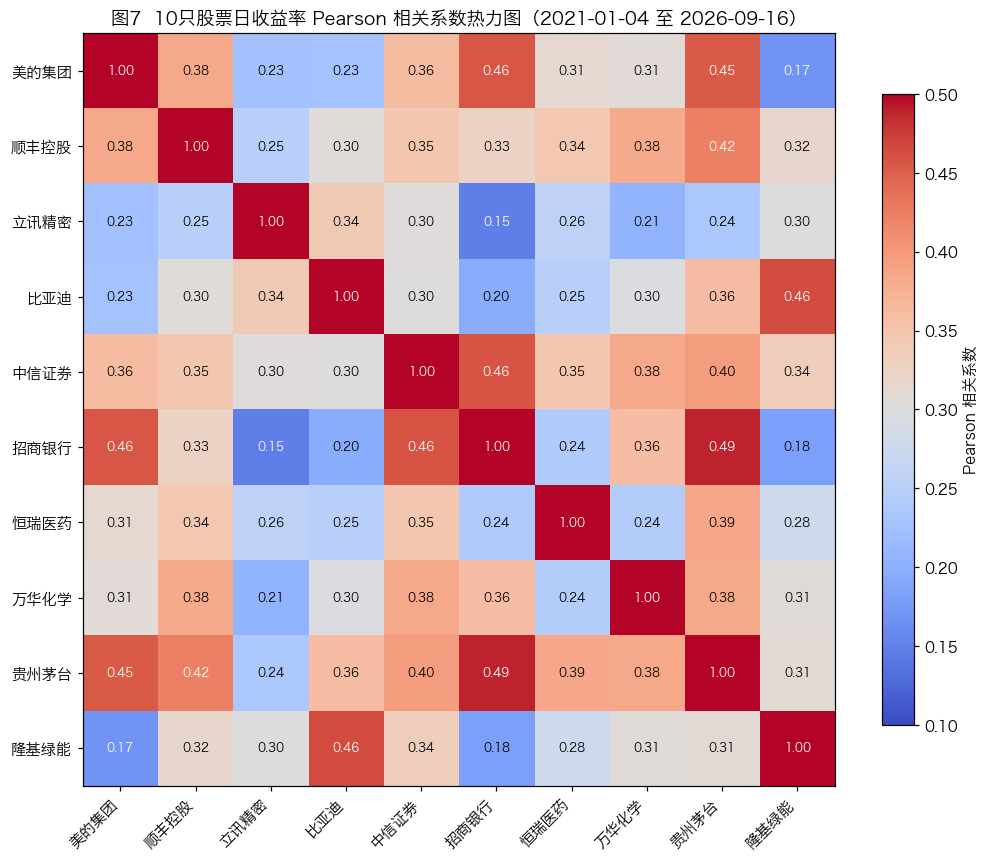

In [21]:
# 图7：Pearson 相关系数热力图
fig, ax = plt.subplots(figsize=(9.5, 8))
im = ax.imshow(corr.values, cmap="coolwarm", vmin=0.10, vmax=0.50)
ax.set_xticks(range(len(order)))
ax.set_yticks(range(len(order)))
ax.set_xticklabels([names[c] for c in order], rotation=45, ha="right")
ax.set_yticklabels([names[c] for c in order])
for i in range(len(order)):
    for j in range(len(order)):
        ax.text(j, i, f"{corr.values[i, j]:.2f}", ha="center", va="center",
                color="white" if abs(corr.values[i, j] - 0.30) > 0.12 else "black", fontsize=8)
cb = fig.colorbar(im, ax=ax, shrink=0.8)
cb.set_label("Pearson 相关系数")
ax.set_title("图7  10只股票日收益率 Pearson 相关系数热力图（2021-01-04 至 2026-09-16）", fontsize=12)
fig.tight_layout()
plt.show()

In [22]:
# 相关系数分布：45 对组合的平均、最高与最低
iu = np.triu_indices_from(corr.values, k=1)
pair_r = corr.values[iu]
pairs = pd.DataFrame({
    "股票A": [names[corr.index[i]] for i in iu[0]],
    "股票B": [names[corr.index[j]] for j in iu[1]],
    "相关系数": pair_r,
})
print("配对数:", len(pairs))
print("平均相关系数:", round(float(pairs["相关系数"].mean()), 4))
print("最高相关系数:", round(float(pairs["相关系数"].max()), 4))
print("最低相关系数:", round(float(pairs["相关系数"].min()), 4))
print("相关系数标准差:", round(float(pairs["相关系数"].std()), 4))
print("\n最相关的 6 对:")
display(pairs.sort_values("相关系数", ascending=False).head(6).round(4))
print("最不相关的 5 对:")
display(pairs.sort_values("相关系数").head(5).round(4))

配对数: 45
平均相关系数: 0.3186
最高相关系数: 0.488
最低相关系数: 0.1483
相关系数标准差: 0.083

最相关的 6 对:


,股票A,股票B,相关系数
37,招商银行,贵州茅台,0.4880
29,比亚迪,隆基绿能,0.4649
30,中信证券,招商银行,0.4588
4,美的集团,招商银行,0.4564
7,美的集团,贵州茅台,0.4542
15,顺丰控股,贵州茅台,0.4226


最不相关的 5 对:


,股票A,股票B,相关系数
19,立讯精密,招商银行,0.1483
8,美的集团,隆基绿能,0.1689
38,招商银行,隆基绿能,0.1813
25,比亚迪,招商银行,0.1955
21,立讯精密,万华化学,0.2078


In [23]:
# 成对有效样本量：确认 pairwise 口径下每对实际用了多少天
valid = ret_wide.notna().astype(int)
pair_n = valid.T.dot(valid)
pn = pair_n.values[np.triu_indices_from(pair_n.values, k=1)]
print("成对有效样本量: 最小", int(pn.min()), " 最大", int(pn.max()), " 中位数", int(np.median(pn)))

# 共同样本口径（listwise）作对照，检验日期对齐方式是否影响结论
common = ret_wide.dropna()
corr_common = common.corr()
print("共同样本行数:", len(common))
print("平均相关系数: pairwise", round(float(pairs['相关系数'].mean()), 4),
      " 共同样本", round(float(corr_common.values[iu].mean()), 4))
print("两种口径下单个相关系数差异的最大绝对值:",
      round(float(np.nanmax(np.abs(corr.values - corr_common.values))), 4))

成对有效样本量: 最小 1373  最大 1384  中位数 1384
共同样本行数: 1373
平均相关系数: pairwise 0.3186  共同样本 0.3183
两种口径下单个相关系数差异的最大绝对值: 0.0079


In [24]:
# 同行业与板块对照：检验"同行业是否更相关"
industry_map = d.drop_duplicates("stock_code").set_index("stock_code")["industry"].to_dict()
print("各行业包含的股票数:")
print(pd.Series({names[c]: industry_map[c] for c in order}).value_counts().to_string())

same_industry = [("000333.SZ", "601012.SH")]   # 美的集团、隆基绿能：电气机械和器材制造业
financial = [("600036.SH", "600030.SH")]       # 招商银行、中信证券：金融板块
rows = []
for a, b in same_industry:
    rows.append({"分组": "同行业（电气机械和器材制造业）", "股票A": names[a], "股票B": names[b],
                 "相关系数": corr.loc[a, b]})
for a, b in financial:
    rows.append({"分组": "金融板块（银行+证券）", "股票A": names[a], "股票B": names[b],
                 "相关系数": corr.loc[a, b]})
rows.append({"分组": "其余43对照", "股票A": "—", "股票B": "—",
             "相关系数": float(pd.Series(pair_r).drop(
                 [list(zip(iu[0], iu[1])).index((order.index("000333.SZ"), order.index("601012.SH")))]
             ).mean())})
display(pd.DataFrame(rows).round(4))
print("同行业对在45对中的分位数:",
      round(float((pd.Series(pair_r) < corr.loc["000333.SZ", "601012.SH"]).mean()), 3))

# 用平均相关系数推算等权组合波动率的理论值，与第 4 节实测值对照
n_assets = len(order)
rho_bar = float(pairs["相关系数"].mean())
theory = np.sqrt(1 / n_assets + (1 - 1 / n_assets) * rho_bar)
print("\n等方差近似下组合/个股波动率理论值:", round(float(theory), 4))
print("第4节实测值（组合标准差 / 个股标准差均值）: 0.618") 

各行业包含的股票数:
电气机械和器材制造业          2
邮政业                 1
计算机、通信和其他电子设备制造业    1
汽车制造业               1
资本市场服务              1
货币金融服务              1
医药制造业               1
化学原料和化学制品制造业        1
酒、饮料和精制茶制造业         1


,分组,股票A,股票B,相关系数
0,同行业（电气机械和器材制造业）,美的集团,隆基绿能,0.1689
1,金融板块（银行+证券）,招商银行,中信证券,0.4588
2,其余43对照,—,—,0.3220


同行业对在45对中的分位数: 0.022

等方差近似下组合/个股波动率理论值: 0.6219
第4节实测值（组合标准差 / 个股标准差均值）: 0.618


### Step 3：Markdown结果解读

10只股票的日收益率**全部正相关**，45对组合的平均相关系数为0.3186，最高的招商银行—贵州茅台为0.4880，最低的立讯精密—招商银行为0.1483，整体处于中等偏低水平。这个水平本身解释了第4节的分散化结果：在等方差近似下，n只资产等权组合的波动率与个股波动率之比为 $\sqrt{1/n+(1-1/n)\bar{\rho}}$，代入 n=10、$\bar{\rho}=0.3186$ 得到**理论值0.6219，与第4节实测的0.618几乎一致**。也就是说，组合波动率降到个股的六成，完全可以由"10只资产 + 平均相关0.32"解释，不需要额外假设。

**同行业是否更相关——本样本给出的答案是否定的，而且相当明确。** 10只股票唯一同属一个CSMAR行业的一对是美的集团与隆基绿能（均为电气机械和器材制造业），其相关系数仅**0.1689，在45对中排倒数第二**，远低于平均值0.3186；而跨行业的招商银行—贵州茅台反而以0.4880位居第一。金融板块的招商银行与中信证券为0.4588，明显高于平均。

这个结果需要谨慎解释，不能反过来读成"同行业一定不相关"。原因有三：其一，本样本**只有一对同行业股票**，单对观测不足以检验行业属性的作用，0.1689 这个数值可能只是这对股票自身的特性；其二，CSMAR的"电气机械和器材制造业"是门类级分类，美的集团是家电终端消费品、隆基绿能是光伏设备制造商，两者的终端需求、产业链位置与驱动因素差别很大，粗分类并不能保证基本面共动；其三，招商银行—贵州茅台的高相关更可能来自"核心资产"与大盘因子的共同驱动，而非行业属性。因此本节的结论是：**在本样本中，粗粒度的行业分类并不能预测日收益率的相关性，行业标签不是分组的充分依据**——这一点对第7节的组合构造也有直接含义。

日期对齐方式对结论没有实质影响：pairwise 口径的平均相关系数为0.3186，共同样本（1,373天）口径为0.3183，单个相关系数差异的最大绝对值只有0.0079。这印证了第2节的判断——9个停牌日与2个跨期收益造成的缺失占比极小，任何一种合理的对齐方式都不会改变结论。成对有效样本量最少1,373天、最多1,384天，仍在1,300天以上，估计精度有保障。

最后需要说明相关系数的边界：它只刻画线性共动，不区分"共同因子驱动"与"相互传染"，也不蕴含因果；两个高相关可能只是因为都跟随大盘。此外，相关系数在全样本期是静态的，而第4节显示波动存在时间聚集，危机时期的相关性通常上升，因此用全样本相关估计的风险分散效果在极端行情下可能过于乐观。

核心发现：

- 10只股票日收益全部正相关，平均0.3186，最高0.4880（招行—茅台），最低0.1483（立讯—招行）；
- 平均相关0.32 + 10只资产，理论上把组合波动率降至个股的0.6219倍，与第4节实测0.618吻合；
- 唯一的同行业对（美的—隆基）相关0.1689，排45对中倒数第二，行业粗分类不能预测相关性；
- 日期对齐方式影响极小（两种口径平均相关相差0.0003），结论稳健。

## 7. 等权组合与滞后总市值加权组合

### Step 1：Markdown分析说明

本节要回答三个问题：第一，两种权重的组合表现差多少；第二，差异来自哪里——是权重集中程度，还是被重仓股票自身表现；第三，组合相对个股的分散作用有多大。

组合构造按作业给定的教学设定：每日按目标权重计算收益、忽略交易成本。

$$r^{EW}_{p,t}=\sum_{i=1}^{10}0.1\,r_{i,t},\qquad
w_{i,t-1}=\frac{MV_{i,t-1}}{\sum_{j=1}^{10}MV_{j,t-1}},\quad
r^{VW}_{p,t}=\sum_{i=1}^{10}w_{i,t-1}r_{i,t}$$

其中 $MV_{i,t-1}$ 是上一交易日收盘时的**总市值**，用不复权收盘价与巨潮总股本构造，不用流通市值、不用当前市值回填、不用复权价乘股本。

缺失行情与市值的处理规则如下：某只股票当日停牌或当日收益为跨期收益被剔除时，**该股当日不进入组合，权重在其余可用股票之间重新归一化**，两种组合都按此处理；因此停牌日的等权组合实际是"9只或8只股票等权"，而不是给缺失股票填零。市值权重需要上一交易日市值，若上一交易日该股停牌，则沿用其最近一次可观测市值。

分析要点与检查事项：

- 评价期间：两组合使用完全相同的1,384个交易日（2021-01-04至2026-09-16），保证可比；
- 权重核验：逐日检查两种权重之和是否为1；
- 比较指标：累计收益与净值曲线、几何年化收益率、年化波动率、最大回撤；
- 年化波动率由组合日收益序列直接计算，**不能用个股波动率的加权平均**代替；
- 权重集中度：用平均权重、赫芬达尔指数（HHI）与前三大权重占比刻画；
- 边界：这是事后选定样本的事后测算，不等同于历史可实施策略，也不预示未来收益。

### Step 2：代码与实际输出

下面先构造权重并核验，再计算组合收益与评价指标，最后给出净值曲线、回撤曲线与权重集中度。

In [25]:
# 构造 日期 × 股票 的收益矩阵与市值矩阵（市值矩阵含 2020-12-31 支持日）
ret_all = d.pivot(index="date", columns="stock_code", values="ret")
mv_all = d.pivot(index="date", columns="stock_code", values="market_cap_100m_cny")
R = ret_all.loc[ret_all.index >= "2021-01-01"].reindex(columns=order)

# 上一交易日总市值：停牌日沿用该股最近一次可观测市值，再整体滞后一期
mv_lag = mv_all.ffill().shift(1).loc[R.index]

available = R.notna()                      # 当日有有效收益的股票
n_avail = available.sum(axis=1)
print("评价期间:", R.index[0].date(), "至", R.index[-1].date(), " 交易日数 T =", len(R))
print("每日可用股票数: 最小", int(n_avail.min()), " 最大", int(n_avail.max()))
print("可用股票数小于10的天数:", int((n_avail < 10).sum()), "（停牌日与复牌日）")
print("滞后市值缺失数:", int(mv_lag.isna().sum().sum()))

# 等权权重：在当日可用股票之间等权（等价于给每只可用股票 1/n_avail）
w_eq = available.div(n_avail, axis=0)
# 市值加权权重：用 t-1 总市值，同样只在当日可用股票之间归一化
mv_eff = mv_lag.where(available)
w_vw = mv_eff.div(mv_eff.sum(axis=1), axis=0)

print("\n权重和核验：")
print("  等权  权重和 最小值", round(float(w_eq.sum(axis=1).min()), 10),
      " 最大值", round(float(w_eq.sum(axis=1).max()), 10))
print("  市值  权重和 最小值", round(float(w_vw.sum(axis=1).min()), 10),
      " 最大值", round(float(w_vw.sum(axis=1).max()), 10))

评价期间: 2021-01-04 至 2026-09-16  交易日数 T = 1384
每日可用股票数: 最小 9  最大 10
可用股票数小于10的天数: 11 （停牌日与复牌日）
滞后市值缺失数: 0

权重和核验：
  等权  权重和 最小值 1.0  最大值 1.0
  市值  权重和 最小值 1.0  最大值 1.0


In [26]:
# 组合日收益与净值
r_ew = (w_eq * R.fillna(0)).sum(axis=1)
r_vw = (w_vw * R.fillna(0)).sum(axis=1)
nav_ew = (1 + r_ew).cumprod()
nav_vw = (1 + r_vw).cumprod()


def portfolio_metrics(r, nav, label):
    dd = nav / nav.cummax() - 1
    return {
        "组合": label,
        "评价期交易日数 T": len(r),
        "累计净值": nav.iloc[-1],
        "累计收益": nav.iloc[-1] - 1,
        "几何年化收益率": (1 + r).prod() ** (252 / len(r)) - 1,
        "年化波动率": r.std() * np.sqrt(252),
        "最大回撤": -dd.min(),
        "回撤谷底日期": str(dd.idxmin().date()),
    }


metrics_tbl = pd.DataFrame([
    portfolio_metrics(r_ew, nav_ew, "等权组合"),
    portfolio_metrics(r_vw, nav_vw, "市值加权组合"),
]).set_index("组合")
display(metrics_tbl.round(6))

diff = metrics_tbl.drop(columns=["评价期交易日数 T", "回撤谷底日期"]).loc["市值加权组合"] - \
       metrics_tbl.drop(columns=["评价期交易日数 T", "回撤谷底日期"]).loc["等权组合"]
print("差异（市值加权 − 等权）:")
print(diff.round(6).to_string())
print("\n两组合日收益的相关系数:", round(float(np.corrcoef(r_ew, r_vw)[0, 1]), 4))

,评价期交易日数 T,累计净值,累计收益,几何年化收益率,年化波动率,最大回撤,回撤谷底日期
组合,,,,,,,
等权组合,1384,0.908921,-0.091079,-0.017238,0.207027,0.432771,2024-02-02
市值加权组合,1384,0.851233,-0.148767,-0.028902,0.205559,0.437060,2022-10-31


差异（市值加权 − 等权）:
累计净值      -0.057688
累计收益      -0.057688
几何年化收益率   -0.011664
年化波动率     -0.001468
最大回撤       0.004289

两组合日收益的相关系数: 0.9412


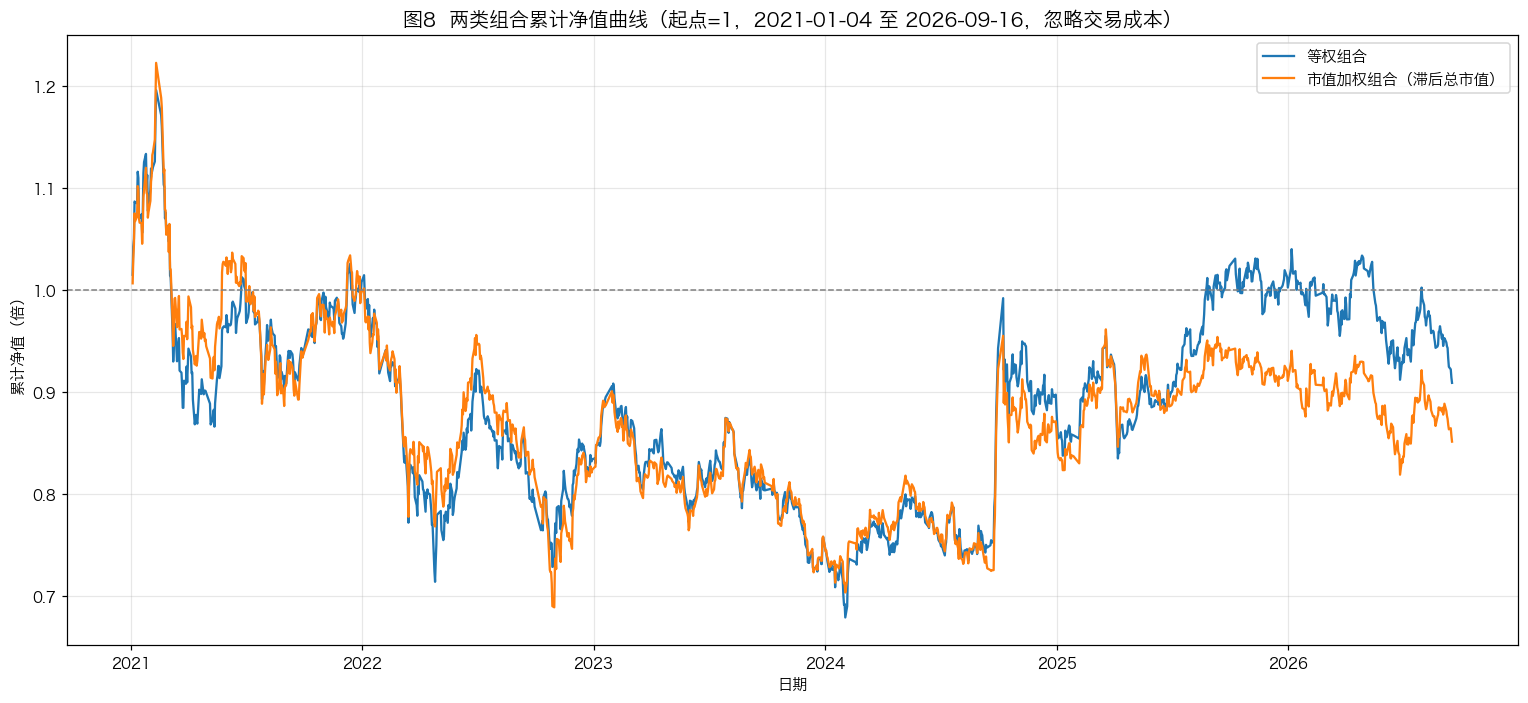

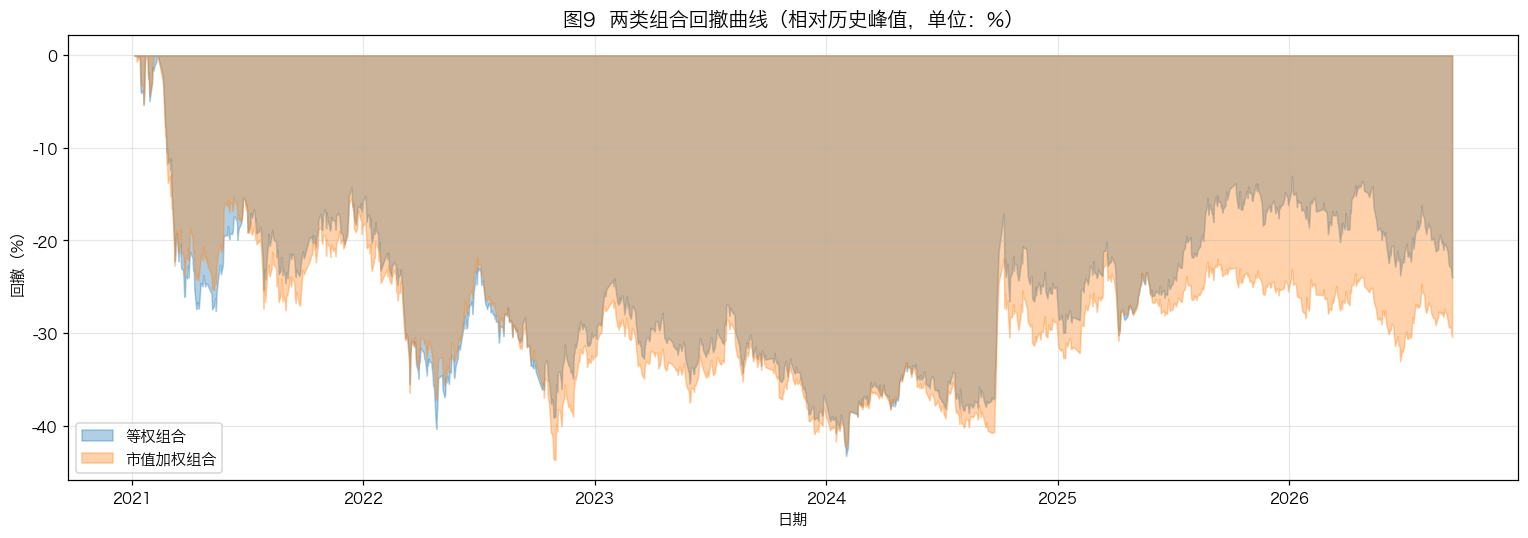

In [27]:
# 图8：两组合净值曲线
fig, ax = plt.subplots(figsize=(14, 6.5))
ax.plot(nav_ew.index, nav_ew, label="等权组合", color="tab:blue", linewidth=1.5)
ax.plot(nav_vw.index, nav_vw, label="市值加权组合（滞后总市值）", color="tab:orange", linewidth=1.5)
ax.axhline(1.0, color="gray", linestyle="--", linewidth=1)
ax.set_title("图8  两类组合累计净值曲线（起点=1，2021-01-04 至 2026-09-16，忽略交易成本）", fontsize=13)
ax.set_xlabel("日期")
ax.set_ylabel("累计净值（倍）")
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()

# 图9：回撤曲线
fig, ax = plt.subplots(figsize=(14, 5))
dd_ew = nav_ew / nav_ew.cummax() - 1
dd_vw = nav_vw / nav_vw.cummax() - 1
ax.fill_between(dd_ew.index, dd_ew * 100, 0, color="tab:blue", alpha=0.35, label="等权组合")
ax.fill_between(dd_vw.index, dd_vw * 100, 0, color="tab:orange", alpha=0.35, label="市值加权组合")
ax.set_title("图9  两类组合回撤曲线（相对历史峰值，单位：%）", fontsize=13)
ax.set_xlabel("日期")
ax.set_ylabel("回撤（%）")
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()

In [28]:
# 权重集中度：平均权重、HHI 与等效分散只数
w_mean = w_vw.mean().rename(index=names).sort_values(ascending=False)
display(w_mean.round(4).to_frame("平均市值权重"))

hhi = (w_vw ** 2).sum(axis=1)
top3 = w_vw.apply(lambda row: row.nlargest(3).sum(), axis=1)
concentration = pd.DataFrame({
    "指标": ["HHI 均值", "等效分散只数 1/HHI", "前三大权重合计 均值", "最大个股权重 均值",
           "等权基准 HHI", "等权等效只数"],
    "数值": [hhi.mean(), 1 / hhi.mean(), top3.mean(), w_vw.max(axis=1).mean(), 0.10, 10.0],
})
display(concentration.round(4))
print("个股权重的最大值（单日）:", round(float(w_vw.max().max()), 4),
      " 对应股票:", names[w_vw.max(axis=1).idxmax() and w_vw.max().idxmax()])

,平均市值权重
stock_code,
贵州茅台,0.3449
招商银行,0.1650
比亚迪,0.1306
美的集团,0.0807
中信证券,0.0571
恒瑞医药,0.0527
立讯精密,0.0473
万华化学,0.0439
隆基绿能,0.0396


,指标,数值
0,HHI 均值,0.1865
1,等效分散只数 1/HHI,5.3612
2,前三大权重合计 均值,0.6413
3,最大个股权重 均值,0.3449
4,等权基准 HHI,0.1000
5,等权等效只数,10.0000


个股权重的最大值（单日）: 0.4174  对应股票: 贵州茅台


### Step 3：Markdown结果解读

两个组合在相同的1,384个交易日（2021-01-04至2026-09-16）上评价，权重和逐日核验恒为1，滞后总市值无缺失。**两个组合在样本期内都是亏损的**：等权组合累计净值0.9089（−9.11%），几何年化收益率−1.72%；市值加权组合累计净值0.8512（−14.88%），几何年化收益率−2.89%。这与第3节"4只上涨、6只下跌"的个股分布一致——多数股票下跌时，组合难以独善其身。

**市值加权比等权多亏5.77个百分点**（几何年化低1.17个百分点），差异来源是权重集中与被重仓股票的表现。市值加权组合中贵州茅台的平均权重高达34.49%（单日最高41.74%），招商银行16.50%、比亚迪13.06%，前三大合计64.13%；HHI均值0.1865，对应**等效分散只数仅5.36只**，远低于等权的10只。而贵州茅台恰恰是样本期内表现较差的股票之一（累计净值0.7353，−26.47%），把三分之一以上的权重压在一只下跌26%的股票上，直接拖累了整个组合。等权组合给每只股票10%的固定权重，既限制了茅台的拖累，也充分分享了比亚迪（+33.99%）的上涨。

值得注意的是，**集中度提高并没有换来更高的波动，也没有换来更高收益**：两组合年化波动率几乎相同（等权20.70%、市值加权20.56%，市值加权反而低0.15个百分点），最大回撤也非常接近（43.28%对43.71%）。原因是权重最集中的贵州茅台本身是个股中波动率较低的（27.25%，倒数第三），所以向它集中既没有放大波动，也没有改善收益——只是把收益风险特征向这只股票靠拢。两个组合的日收益相关系数高达0.9412，说明权重差异并没有改变组合的日度行为，差异主要来自个别重仓股的长期走势。

回撤曲线给出了另一个角度：两组合的最大回撤幅度接近，但**谷底时间不同**——等权组合最深回撤出现在2024-02-02（43.28%），市值加权组合出现在2022-10-31（43.71%）。等权组合中小市值股票权重更高，在2024年初的小微盘流动性冲击中受损更明显；市值加权组合则更早见底。这说明权重的差异不仅影响收益水平，也改变了组合对不同类型市场冲击的敏感度。

分散投资的作用在这里得到最终确认：两个组合的年化波动率都在20.6%左右，而10只个股的年化波动率均值是33.52%、最低的招商银行也有26.82%。也就是说，**无论用哪种权重，把10只股票放在一起都把波动降到个股水平的六成左右**，这与第4节的实测（0.618）和第6节的理论推算（0.6219）完全一致。

最后必须说明本节的边界。其一，这是**事后测算**：股票池按行业与商业模式事先选定，但组合并非历史实际持有，也没有考虑交易成本——每日按目标权重再平衡在现实中会产生换手成本，市值加权组合的换手通常低于等权组合，这一差异在本节被忽略了。其二，样本期内两个组合都亏损，这与A股2021年以来的整体走势有关，不能据此判断两种权重方式的优劣，更不能外推为未来收益。其三，10只股票的样本极小，权重集中度的结论高度依赖贵州茅台这一只股票的表现，换成另一组股票结论可能完全不同。

核心发现：

- 两组合均亏损：等权累计−9.11%（年化−1.72%），市值加权−14.88%（年化−2.89%），市值加权多亏5.77个百分点；
- 差异源自权重集中：茅台平均权重34.49%，等效分散只数仅5.36只，而茅台累计下跌26.47%；
- 集中度提高既未增加波动（20.56% 对 20.70%）也未改善收益，最大回撤接近但谷底时点不同（2022-10 对 2024-02）；
- 分散作用确认：两组合波动率约20.6%，远低于个股均值33.52%，与第4、6节结论互相印证。

## 后续分析结构

最后一节继续采用“Step 1分析说明—Step 2代码与实际输出—Step 3结果解读”：

8. 总体结论、局限与AI使用说明
